In [ ]:
import sys
sys.version

'3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]'

# **為替レート予測**

以下のコードでは、量子QRCと古典ESNを使った為替レートの予測を行う。

なお、データはinvesting.comより取得した2022/1/5-2026-1/5の日次終値を用いている。

**このコードを動かすためには、rate.csvが必要である。このcsvファイルは同じgithub内に置いてある。**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from typing import Tuple, Optional, Dict

# -------------------------
# データセット: 入力 U=x(t), 教師 Y=x(t+1)
# -------------------------
def make_scalar_dataset_next(x_series: np.ndarray, start_t: int, T: int):
    x = np.asarray(x_series, float).reshape(-1)
    if start_t < 0:
        raise ValueError("start_t must be >= 0")
    if start_t + T + 101 > len(x):
        raise ValueError("range out of x_series (need t+101)")
    U = x[start_t : start_t + T]                     # (T,)
    Y = x[start_t + 101 : start_t + T + 101]         # (T,)  ★ y[t+101]
    return U, Y

# -------------------------
# 共通: ridge readout（bias付き、biasは正則化しない）
# -------------------------
def fit_readout_ridge(S: np.ndarray, Y: np.ndarray, ridge: float = 1e-2) -> Tuple[np.ndarray, float]:
    S = np.asarray(S, float)
    Y = np.asarray(Y, float).reshape(-1)
    T, M = S.shape
    if Y.size != T:
        raise ValueError("S and Y length mismatch")
    X = np.hstack([S, np.ones((T, 1))])  # (T, M+1)
    Reg = np.diag(np.append(np.full(M, ridge), 0.0))  # biasは正則化しない
    theta = np.linalg.solve(X.T @ X + Reg, X.T @ Y)
    w = theta[:M]
    b = float(theta[M])
    return w, b

def predict_readout(S: np.ndarray, w: np.ndarray, b: float) -> np.ndarray:
    return np.asarray(S, float) @ np.asarray(w, float) + float(b)

def mse_corr(y_true: np.ndarray, y_pred: np.ndarray) -> Tuple[float, float]:
    y_true = np.asarray(y_true, float).reshape(-1)
    y_pred = np.asarray(y_pred, float).reshape(-1)
    mse = float(np.mean((y_true - y_pred) ** 2))
    corr = float(np.corrcoef(y_true, y_pred)[0, 1])
    return mse, corr

def plot_true_vs_pred(y_true, y_pred, title=""):
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)
    plt.figure(figsize=(12, 4))
    plt.plot(y_true, label="True", lw=2)
    plt.plot(y_pred, label="Predicted", lw=1.5, alpha=0.85)
    plt.title(title)
    plt.xlabel("time index")
    plt.ylabel("x")
    plt.legend()
    plt.tight_layout()
    plt.show()


# =========================================================
# (A) QRC: out_prob 状態列（入力はスカラー）
# =========================================================
def simulate_qrc_states_outprob_scalar(
    N: int,
    alpha: float,
    beta: float,
    squeeze_r: float,
    U: np.ndarray,             # (T,)  スカラー入力
    *,
    seed: int = 43,
    norm_const: float = 1.0,
    sign_mode: str = "plus",   # "pm" or "plus"
    input_mode: str = "scale", # "scale" or "replace"
    Win: Optional[np.ndarray] = None,     # (1,M)
    Win_scale: float = 1.0,
    carry_state: bool = True,
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Returns:
      S: (T,M) out_prob（検出確率）状態列
      xT: (M,) 最終状態（無励起確率）
    """
    U = np.asarray(U, float).reshape(-1)
    if U.ndim != 1:
        raise ValueError("U must be (T,)")
    T = U.shape[0]
    U1 = U.reshape(T, 1)  # (T,1)

    M = 12 * N
    rng = np.random.default_rng(seed)

    # 入力マスク (1,M)  ※10→1の最小変更
    if Win is None:
        Win = rng.uniform(-1.0, 1.0, size=(1, M)) * float(Win_scale)
    else:
        Win = np.asarray(Win, float)
        if Win.shape != (1, M):
            raise ValueError(f"Win must be (1,{M})")

    # 状態（無励起確率）
    x_state = np.zeros(M, dtype=float)

    sqrt2 = np.sqrt(2.0)
    sqrt3 = np.sqrt(3.0)

    def bs50(a, b):
        return ((a + b) / sqrt2, (-a + b) / sqrt2)

    def apply_pairs_blockwise(vec: np.ndarray, pairs, mix_fn):
        outv = vec.copy()
        for blk in range(N):
            off = 12 * blk
            for (i, j) in pairs:
                a, b = vec[off + i], vec[off + j]
                ai, bj = mix_fn(a, b)
                outv[off + i] = ai
                outv[off + j] = bj
        return outv

    def tri_mix(a, b):
        return ((a + np.sqrt(2.0) * b) / sqrt3, ((-np.sqrt(2.0)) * a + b) / sqrt3)

    S = np.empty((T, M), dtype=float)

    for t in range(T):
        # スカラー → M次元入力
        u_vec = (U1[t] @ Win)  # (M,)
        if input_mode == "scale":
            u_vec = float(beta) * u_vec
        elif input_mode == "replace":
            pass
        else:
            raise ValueError('input_mode must be "scale" or "replace".')

        # ① 確率注入
        p = np.clip(x_state, 0.0, 1.0)
        r_uni = rng.random(M)
        inject_mask = (r_uni >= p)

        if sign_mode == "pm":
            signs = rng.integers(0, 2, size=M) * 2 - 1
        elif sign_mode == "plus":
            signs = np.ones(M, dtype=float)
        else:
            raise ValueError('sign_mode must be "pm" or "plus".')

        s = np.where(inject_mask, signs * float(alpha), 0.0)

        # ②〜⑤ ネットワーク
        pairs_adj = [(k, k + 1) for k in range(0, 12, 2)]
        t2 = apply_pairs_blockwise(s, pairs_adj, bs50)

        rvec = t2.copy()
        for blk in range(N - 1, 0, -1):
            rvec[12 * blk + 3] = t2[12 * (blk - 1) + 3]
            rvec[12 * blk + 8] = t2[12 * (blk - 1) + 8]
        rvec[3] = 0.0
        rvec[8] = 0.0

        pairs_step4 = [(0, 2), (1, 3), (6, 5), (8, 10), (11, 9)]
        v = apply_pairs_blockwise(rvec, pairs_step4, bs50)

        pairs_step5 = [(4, 3), (7, 8)]
        wnet = apply_pairs_blockwise(v, pairs_step5, tri_mix)

        fin = (wnet + u_vec) / np.sqrt(2.0)

        # ⑧ 非線形（安全版）
        coef = 1.0 / np.cosh(squeeze_r)
        tanh_r = np.tanh(squeeze_r)
        log_p0 = np.log(coef) - (np.abs(fin) ** 2) + tanh_r * (fin ** 2)

        re = np.real(log_p0)
        im = np.imag(log_p0)
        re = np.clip(re, -700.0, 50.0)
        p0_like = np.exp(re + 1j * im)

        out_prob = 1.0 - (p0_like / float(norm_const))
        out_prob = np.clip(np.real(out_prob).astype(float), 0.0, 1.0)

        S[t] = out_prob

        if carry_state:
            x_state = np.clip(1.0 - out_prob, 0.0, 1.0)

    return S, x_state


# =========================================================
# (B) 決定論的 ESN (tanh) ：同じ M=12N、入力はスカラー
# =========================================================
def simulate_esn_states_tanh_scalar(
    M: int,
    U: np.ndarray,  # (T,) スカラー入力
    *,
    seed: int = 43,
    spectral_radius: float = 0.9,
    input_scale: float = 0.5,
    leak_rate: float = 1.0,
    bias_scale: float = 0.1,
) -> Tuple[np.ndarray, Dict[str, np.ndarray]]:
    """
    標準的 ESN:
      x_{t+1} = (1-leak)*x_t + leak*tanh( Wres x_t + Win u_t + b )
    Returns:
      S: (T,M) 状態列
      params: Wres, Win, b
    """
    U = np.asarray(U, float).reshape(-1)
    if U.ndim != 1:
        raise ValueError("U must be (T,)")
    T = U.shape[0]

    rng = np.random.default_rng(seed)

    # Win: (1,M)  ※10→1
    Win = rng.uniform(-1.0, 1.0, size=(1, M)) * float(input_scale)

    # Wres: (M,M) を作ってスペクトル半径調整
    Wres = rng.normal(0.0, 1.0, size=(M, M)) / np.sqrt(M)

    eigvals = np.linalg.eigvals(Wres)
    sr = np.max(np.abs(eigvals)) + 1e-12
    Wres = Wres * (float(spectral_radius) / sr)

    b = rng.uniform(-1.0, 1.0, size=M) * float(bias_scale)

    x = np.zeros(M, dtype=float)
    S = np.empty((T, M), dtype=float)

    for t in range(T):
        # u(t) はスカラーなので (1,) にしてから @ Win
        pre = x @ Wres + np.array([U[t]]) @ Win + b
        x_new = np.tanh(pre)
        x = (1.0 - leak_rate) * x + leak_rate * x_new
        S[t] = x

    params = {"Wres": Wres, "Win": Win, "b": b}
    return S, params


# =========================================================
# 実験: QRC vs ESN を同じ M で比較してプロット（スカラー入力）
# =========================================================
def compare_qrc_vs_esn_scalar(
    x_series: np.ndarray,
    *,
    N: int = 100,
    start_t: int = 1000,
    T: int = 1000,
    seed: int = 43,
    # QRC params
    alpha: float = 1.0,
    beta: float = 0.7,
    squeeze_r: float = 0.3,
    norm_const: float = 1.0,
    sign_mode: str = "plus",
    input_mode: str = "scale",
    Win_scale_qrc: float = 1.0,
    carry_state: bool = True,
    ridge: float = 1e-2,
    # ESN params
    spectral_radius: float = 0.9,
    input_scale_esn: float = 0.5,
    leak_rate: float = 1.0,
    bias_scale: float = 0.1,
):
    U, Y = make_scalar_dataset_next(x_series, start_t=start_t, T=T)
    M = 12 * N

    # --- QRC
    S_qrc, _ = simulate_qrc_states_outprob_scalar(
        N=N, alpha=alpha, beta=beta, squeeze_r=squeeze_r,
        U=U,
        seed=seed,
        norm_const=norm_const,
        sign_mode=sign_mode,
        input_mode=input_mode,
        Win=None,
        Win_scale=Win_scale_qrc,
        carry_state=carry_state,
    )
    wq, bq = fit_readout_ridge(S_qrc, Y, ridge=ridge)
    Yhat_qrc = predict_readout(S_qrc, wq, bq)
    mse_qrc, corr_qrc = mse_corr(Y, Yhat_qrc)

    # --- ESN
    S_esn, _ = simulate_esn_states_tanh_scalar(
        M=M, U=U,
        seed=seed,
        spectral_radius=spectral_radius,
        input_scale=input_scale_esn,
        leak_rate=leak_rate,
        bias_scale=bias_scale,
    )
    we, be = fit_readout_ridge(S_esn, Y, ridge=ridge)
    Yhat_esn = predict_readout(S_esn, we, be)
    mse_esn, corr_esn = mse_corr(Y, Yhat_esn)

    print(f"[QRC] M={M}  MSE={mse_qrc:.6f}  Corr={corr_qrc:.6f}")
    print(f"[ESN] M={M}  MSE={mse_esn:.6f}  Corr={corr_esn:.6f}")

    plot_true_vs_pred(Y, Yhat_qrc, title=f"QRC (out_prob) Teacher-forced 1-step | scalar | N={N}, M={M}")
    plot_true_vs_pred(Y, Yhat_esn, title=f"ESN (tanh) Teacher-forced 1-step | scalar | M={M}")

    return {
        "Y": Y,
        "Yhat_qrc": Yhat_qrc,
        "Yhat_esn": Yhat_esn,
        "metrics": {
            "qrc": (mse_qrc, corr_qrc),
            "esn": (mse_esn, corr_esn),
        }
    }

In [ ]:
def make_scalar_dataset_next(x_series: np.ndarray, start_t: int, T: int):
    x = np.asarray(x_series, float).reshape(-1)
    if start_t < 0:
        raise ValueError("start_t must be >= 0")
    # ★ 100ステップ先 = +101（あなたの指定どおり）
    if start_t + T + 101 > len(x):
        raise ValueError("range out of x_series (need t+101)")
    U = x[start_t : start_t + T]                     # (T,)
    Y = x[start_t + 101 : start_t + T + 101]         # (T,)  ★ y[t+101]
    return U, Y


In [ ]:
import pandas as pd
import numpy as np

path = "rate.csv.xlsx"

df = pd.read_excel(path)

# C列2行目以降（= 3列目。0始まりで iloc[:,2]）
x_series_C = df.iloc[:, 2].to_numpy(dtype=float)[::-1]  # 時系列を昇順に反転

# D列2行目以降（= 4列目。0始まりで iloc[:,3]）
x_series_D = df.iloc[:, 3].to_numpy(dtype=float)[::-1]  # 同じく反転

start_t = 365
seed = 43
N = 1

# Tはデータ長に合わせて自動で最大に（ここだけ実行上の安全策）
T_C = len(x_series_C) - start_t - 101
T_D = len(x_series_D) - start_t - 101
if T_C <= 0 or T_D <= 0:
    raise ValueError("start_t が大きすぎるか、データ長が足りません。")

[QRC] M=12  MSE=23.347565  Corr=-0.000000
[ESN] M=12  MSE=23.347565  Corr=0.159670


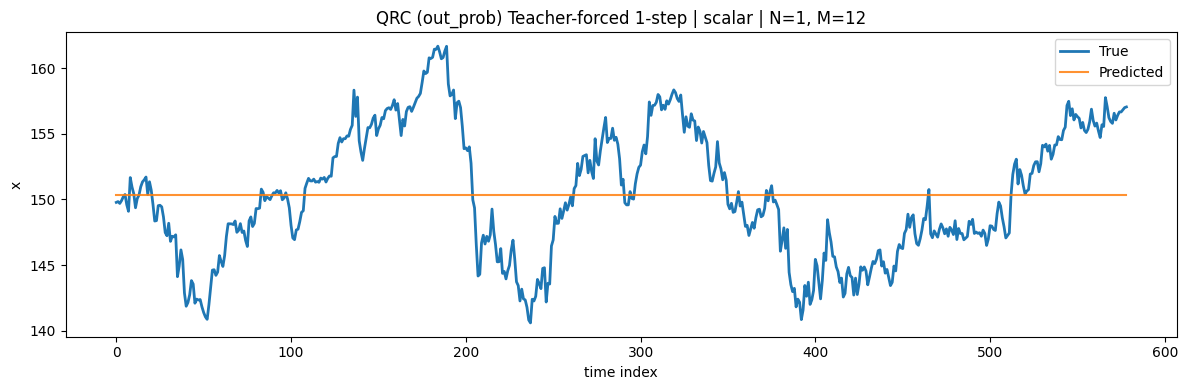

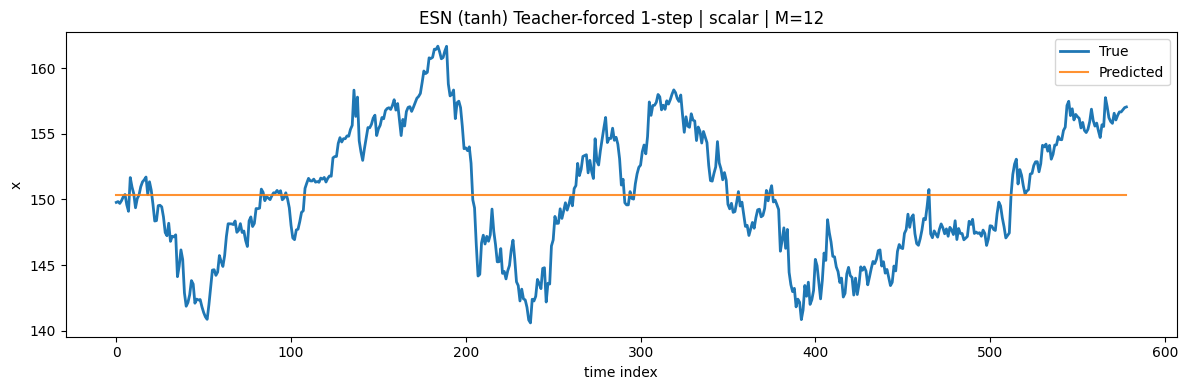

[QRC] M=12  MSE=20.026780  Corr=0.377137
[ESN] M=12  MSE=19.538449  Corr=0.403918


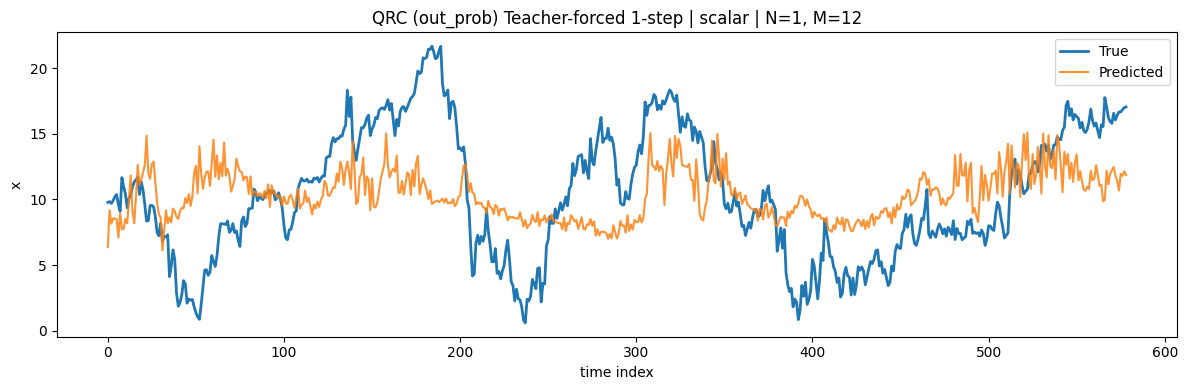

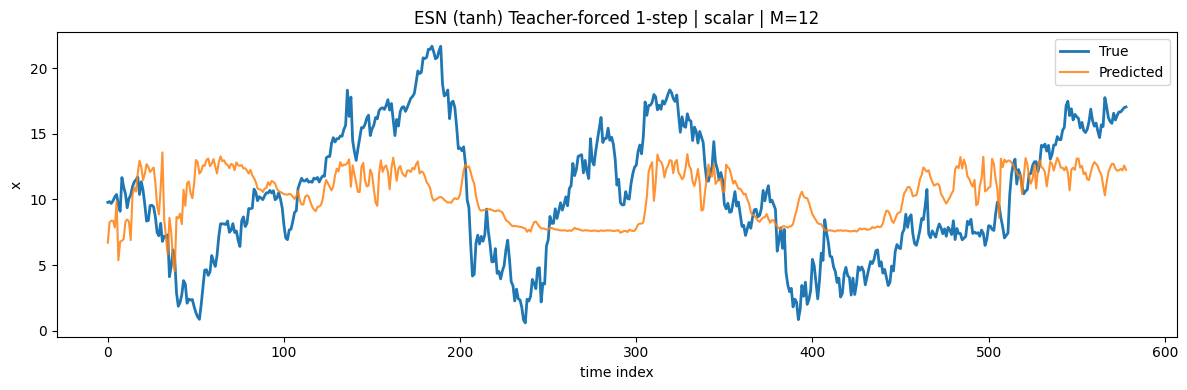

In [ ]:
# ----------------------------
# (A) C列を y(t) として実行
# ----------------------------
res_C = compare_qrc_vs_esn_scalar(
    x_series_C,
    N=N,
    start_t=start_t,
    T=T_C,
    seed=seed,
    # QRC
    alpha=1.0, beta=0.7, squeeze_r=0.3,
    Win_scale_qrc=1.0,
    carry_state=True,
    ridge=1e-2,
    # ESN
    spectral_radius=0.9,
    input_scale_esn=0.5,
    leak_rate=1.0,
    bias_scale=0.1,
)

# ----------------------------
# (B) D列を y(t) として実行
# ----------------------------
res_D = compare_qrc_vs_esn_scalar(
    x_series_D,
    N=N,
    start_t=start_t,
    T=T_D,
    seed=seed,
    # QRC
    alpha=1.0, beta=0.7, squeeze_r=0.3,
    Win_scale_qrc=1.0,
    carry_state=True,
    ridge=1e-2,
    # ESN
    spectral_radius=0.9,
    input_scale_esn=0.5,
    leak_rate=1.0,
    bias_scale=0.1,
)

[QRC] M=120  MSE=22.103056  Corr=0.230890
[ESN] M=120  MSE=22.115705  Corr=0.229949


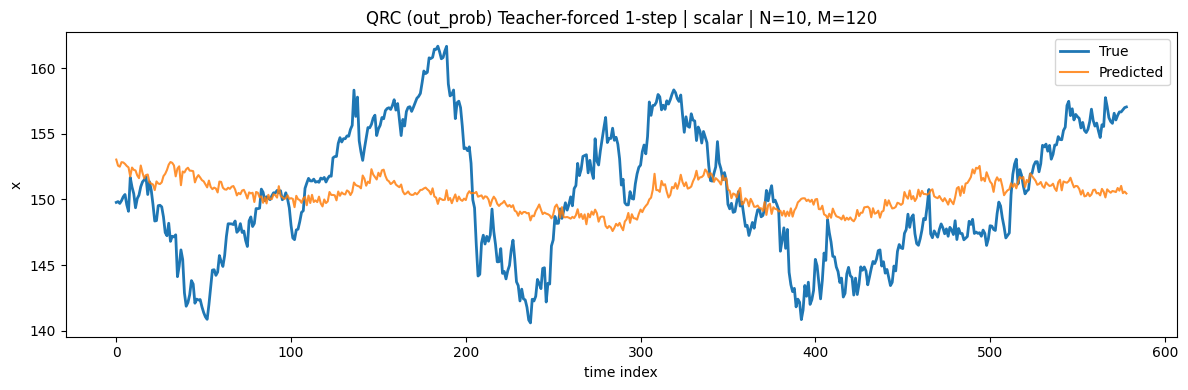

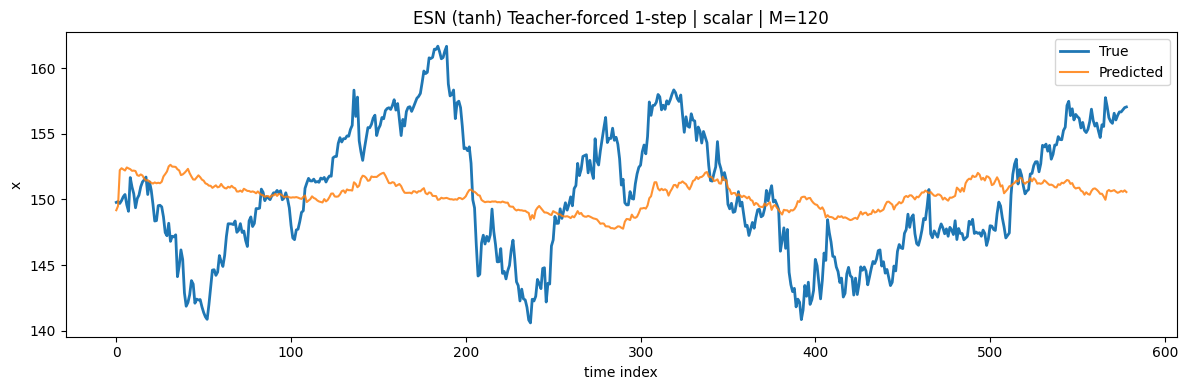

[QRC] M=120  MSE=14.677547  Corr=0.609385
[ESN] M=120  MSE=16.012063  Corr=0.561335


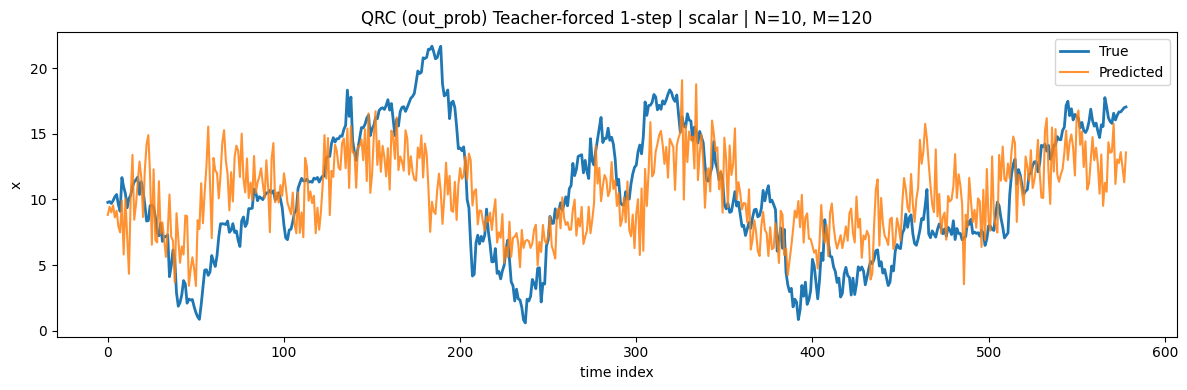

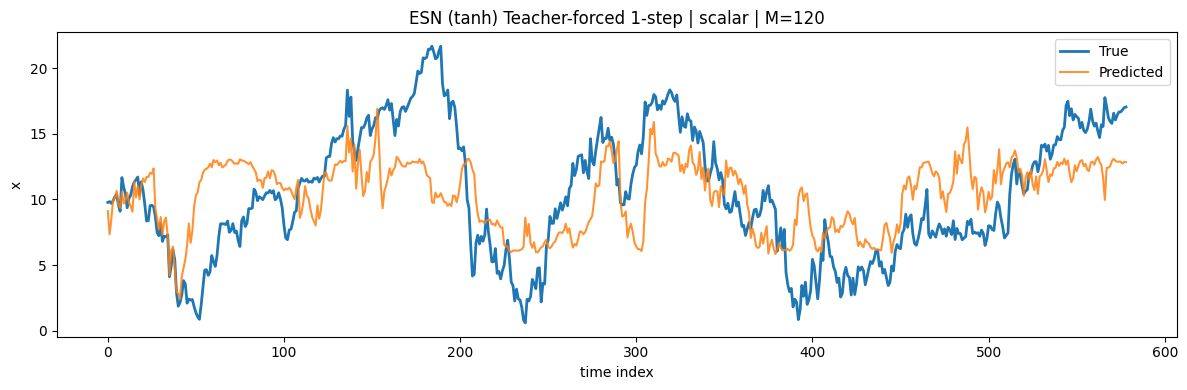

In [ ]:
# ----------------------------
# (A) C列を y(t) として実行
# ----------------------------
res_C = compare_qrc_vs_esn_scalar(
    x_series_C,
    N=10,
    start_t=start_t,
    T=T_C,
    seed=seed,
    # QRC
    alpha=1.0, beta=0.7, squeeze_r=0.3,
    Win_scale_qrc=1.0,
    carry_state=True,
    ridge=1e-2,
    # ESN
    spectral_radius=0.9,
    input_scale_esn=0.5,
    leak_rate=1.0,
    bias_scale=0.1,
)

# ----------------------------
# (B) D列を y(t) として実行
# ----------------------------
res_D = compare_qrc_vs_esn_scalar(
    x_series_D,
    N=10,
    start_t=start_t,
    T=T_D,
    seed=seed,
    # QRC
    alpha=1.0, beta=0.7, squeeze_r=0.3,
    Win_scale_qrc=1.0,
    carry_state=True,
    ridge=1e-2,
    # ESN
    spectral_radius=0.9,
    input_scale_esn=0.5,
    leak_rate=1.0,
    bias_scale=0.1,
)

[QRC] M=1200  MSE=20.188962  Corr=0.368477
[ESN] M=1200  MSE=21.916500  Corr=0.248051


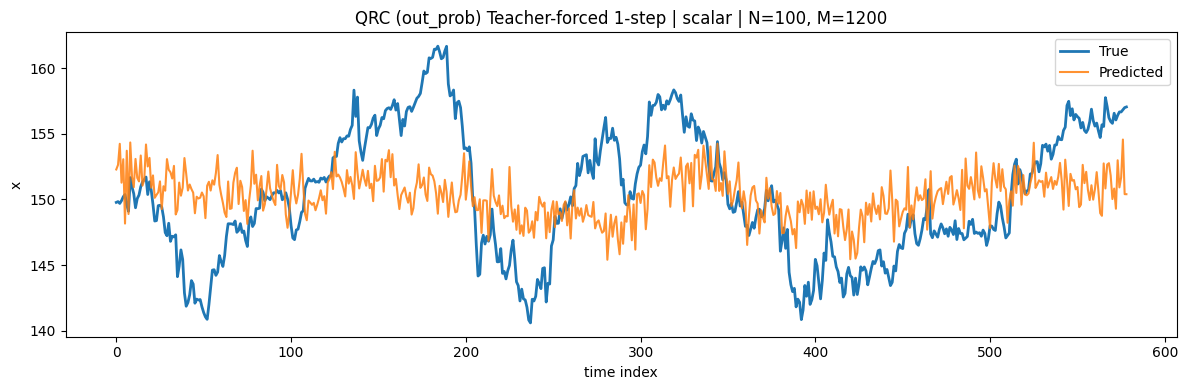

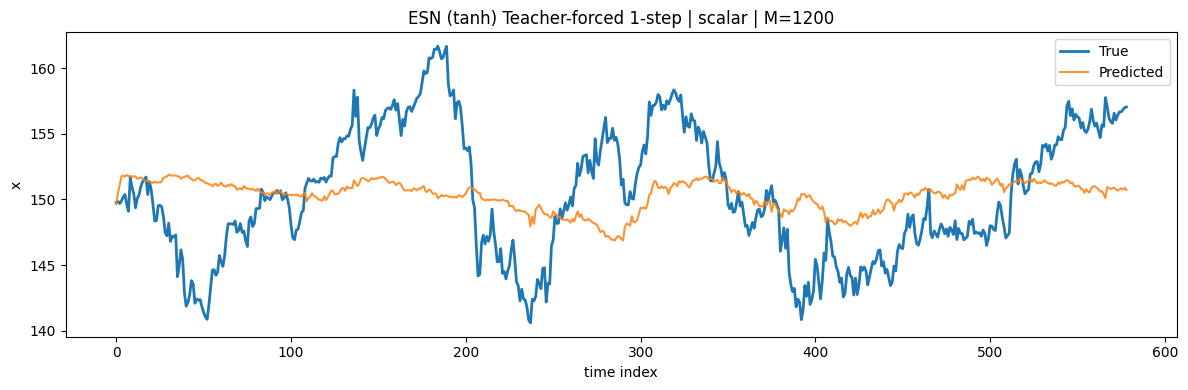

[QRC] M=1200  MSE=0.032277  Corr=0.999358
[ESN] M=1200  MSE=13.131299  Corr=0.663336


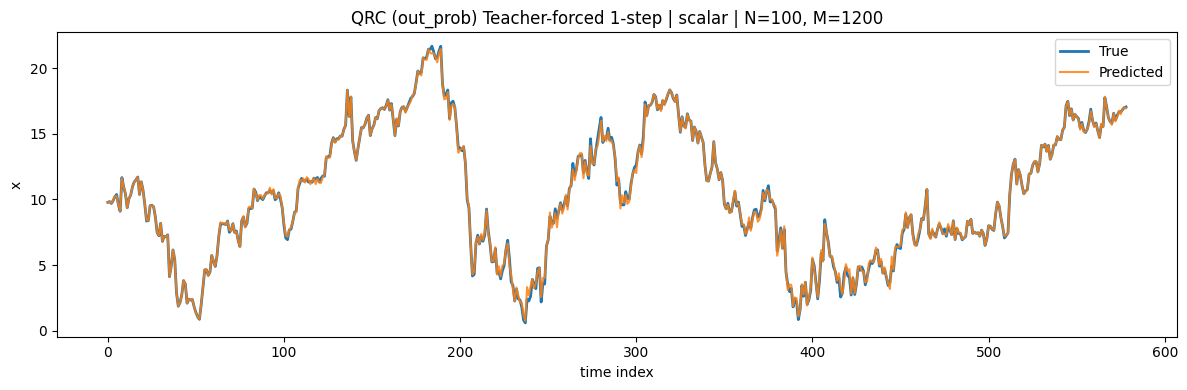

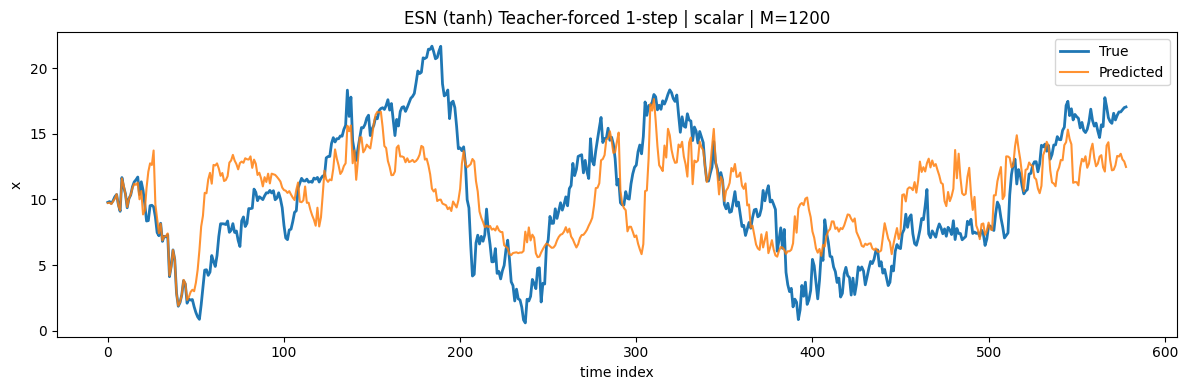

In [ ]:
# ----------------------------
# (A) C列を y(t) として実行
# ----------------------------
res_C = compare_qrc_vs_esn_scalar(
    x_series_C,
    N=100,
    start_t=start_t,
    T=T_C,
    seed=seed,
    # QRC
    alpha=1.0, beta=0.7, squeeze_r=0.3,
    Win_scale_qrc=1.0,
    carry_state=True,
    ridge=1e-2,
    # ESN
    spectral_radius=0.9,
    input_scale_esn=0.5,
    leak_rate=1.0,
    bias_scale=0.1,
)

# ----------------------------
# (B) D列を y(t) として実行
# ----------------------------
res_D = compare_qrc_vs_esn_scalar(
    x_series_D,
    N=100,
    start_t=start_t,
    T=T_D,
    seed=seed,
    # QRC
    alpha=1.0, beta=0.7, squeeze_r=0.3,
    Win_scale_qrc=1.0,
    carry_state=True,
    ridge=1e-2,
    # ESN
    spectral_radius=0.9,
    input_scale_esn=0.5,
    leak_rate=1.0,
    bias_scale=0.1,
)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from typing import Tuple, Optional, Dict

# =========================================================
# Trueは最初のTだけ、PredはT+Hまで描く（TrueはH以降NaNで線を切る）
# =========================================================
def plot_true_and_pred_with_tail(y_true_T, y_pred_TplusH, H, title=""):
    y_true_T = np.asarray(y_true_T, float).reshape(-1)
    y_pred_TplusH = np.asarray(y_pred_TplusH, float).reshape(-1)

    T = len(y_true_T)
    if len(y_pred_TplusH) != T + H:
        raise ValueError("length mismatch: y_pred must be T+H")

    # TrueはT以降をNaNにして描画を止める
    y_true_pad = np.concatenate([y_true_T, np.full(H, np.nan)])

    plt.figure(figsize=(12, 4))
    plt.plot(y_true_pad, label="True (available only up to T)", lw=2)
    plt.plot(y_pred_TplusH, label="Predicted (extended)", lw=1.5, alpha=0.85)
    plt.axvline(T - 1, linestyle="--", linewidth=1)  # ここまでが教師あり
    plt.title(title)
    plt.xlabel("time index (aligned to target x[t+101])")
    plt.ylabel("x")
    plt.legend()
    plt.tight_layout()
    plt.show()


# =========================================================
# 「教師ありT点」+「教師なしH点」まで予測する比較関数（スカラー入力）
# ※あなたの simulate_qrc_states_outprob_scalar / simulate_esn_states_tanh_scalar
#   fit_readout_ridge / predict_readout / mse_corr / make_scalar_dataset_next
#   をそのまま使います
# =========================================================
def compare_qrc_vs_esn_scalar_extend(
    x_series: np.ndarray,
    *,
    N: int = 1,
    start_t: int = 365,
    T: int = 1000,
    seed: int = 43,
    H: int = 101,  # ← ここが「教師なしで延長したい点数（=101）」、かつ学習の先読み幅も101想定
    # QRC params
    alpha: float = 1.0,
    beta: float = 0.7,
    squeeze_r: float = 0.3,
    norm_const: float = 1.0,
    sign_mode: str = "plus",
    input_mode: str = "scale",
    Win_scale_qrc: float = 1.0,
    carry_state: bool = True,
    ridge: float = 1e-2,
    # ESN params
    spectral_radius: float = 0.9,
    input_scale_esn: float = 0.5,
    leak_rate: float = 1.0,
    bias_scale: float = 0.1,
):
    # -----------------------------
    # 1) 教師ありデータ（Y = x[t+101]）
    #    ※あなたが既に make_scalar_dataset_next を「+101版」に変更済みという前提
    # -----------------------------
    U_train, Y_train = make_scalar_dataset_next(x_series, start_t=start_t, T=T)

    # 教師なしで延長するには、入力がもうH点必要（U_extra = x[start_t+T : start_t+T+H]）
    x = np.asarray(x_series, float).reshape(-1)
    need_len = start_t + T + H  # 入力としてここまで必要（これが無いと延長できない）
    if need_len > len(x):
        raise ValueError(f"x_series is too short for tail forecast: need len >= {need_len}, got {len(x)}")

    U_all = x[start_t : start_t + T + H]  # (T+H,)

    M = 12 * N

    # -----------------------------
    # 2) QRC: 学習はT点、予測はT+H点
    # -----------------------------
    S_qrc_train, _ = simulate_qrc_states_outprob_scalar(
        N=N, alpha=alpha, beta=beta, squeeze_r=squeeze_r,
        U=U_train,
        seed=seed,
        norm_const=norm_const,
        sign_mode=sign_mode,
        input_mode=input_mode,
        Win=None,
        Win_scale=Win_scale_qrc,
        carry_state=carry_state,
    )
    wq, bq = fit_readout_ridge(S_qrc_train, Y_train, ridge=ridge)

    # 同じseedで「長い入力」を流して状態列を作り、T+H点ぶん予測
    S_qrc_all, _ = simulate_qrc_states_outprob_scalar(
        N=N, alpha=alpha, beta=beta, squeeze_r=squeeze_r,
        U=U_all,
        seed=seed,
        norm_const=norm_const,
        sign_mode=sign_mode,
        input_mode=input_mode,
        Win=None,
        Win_scale=Win_scale_qrc,
        carry_state=carry_state,
    )
    Yhat_qrc_all = predict_readout(S_qrc_all, wq, bq)  # (T+H,)

    # 教師あり部分の指標だけ計算
    mse_qrc, corr_qrc = mse_corr(Y_train, Yhat_qrc_all[:T])

    # -----------------------------
    # 3) ESN: 学習はT点、予測はT+H点
    # -----------------------------
    S_esn_train, _ = simulate_esn_states_tanh_scalar(
        M=M, U=U_train,
        seed=seed,
        spectral_radius=spectral_radius,
        input_scale=input_scale_esn,
        leak_rate=leak_rate,
        bias_scale=bias_scale,
    )
    we, be = fit_readout_ridge(S_esn_train, Y_train, ridge=ridge)

    S_esn_all, _ = simulate_esn_states_tanh_scalar(
        M=M, U=U_all,
        seed=seed,
        spectral_radius=spectral_radius,
        input_scale=input_scale_esn,
        leak_rate=leak_rate,
        bias_scale=bias_scale,
    )
    Yhat_esn_all = predict_readout(S_esn_all, we, be)  # (T+H,)

    mse_esn, corr_esn = mse_corr(Y_train, Yhat_esn_all[:T])

    print(f"[QRC] M={M}  (eval on first T only) MSE={mse_qrc:.6f}  Corr={corr_qrc:.6f}")
    print(f"[ESN] M={M}  (eval on first T only) MSE={mse_esn:.6f}  Corr={corr_esn:.6f}")
    print(f"Tail forecast length (no teacher): H={H}")

    # -----------------------------
    # 4) プロット：TrueはTまで、PredはT+Hまで
    # -----------------------------
    plot_true_and_pred_with_tail(
        Y_train, Yhat_qrc_all, H,
        title=f"QRC: predict x[t+101] (teacher-forced on T, then tail H) | N={N}, M={M}, H={H}"
    )
    plot_true_and_pred_with_tail(
        Y_train, Yhat_esn_all, H,
        title=f"ESN: predict x[t+101] (teacher-forced on T, then tail H) | M={M}, H={H}"
    )

    return {
        "Y_train": Y_train,
        "Yhat_qrc_all": Yhat_qrc_all,  # 長さ T+H（後ろHは教師なし）
        "Yhat_esn_all": Yhat_esn_all,  # 長さ T+H（後ろHは教師なし）
        "metrics_on_T": {
            "qrc": (mse_qrc, corr_qrc),
            "esn": (mse_esn, corr_esn),
        }
    }

[QRC] M=12  (eval on first T only) MSE=23.347565  Corr=-0.000000
[ESN] M=12  (eval on first T only) MSE=23.347565  Corr=0.159670
Tail forecast length (no teacher): H=101


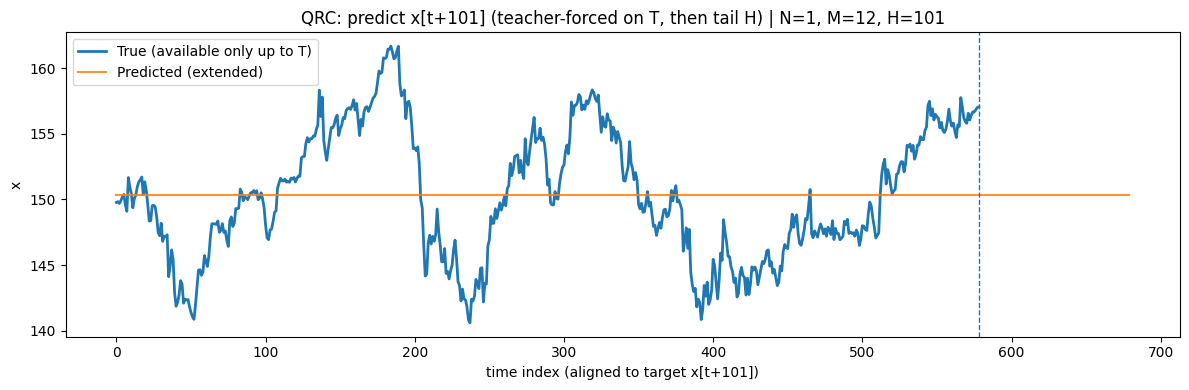

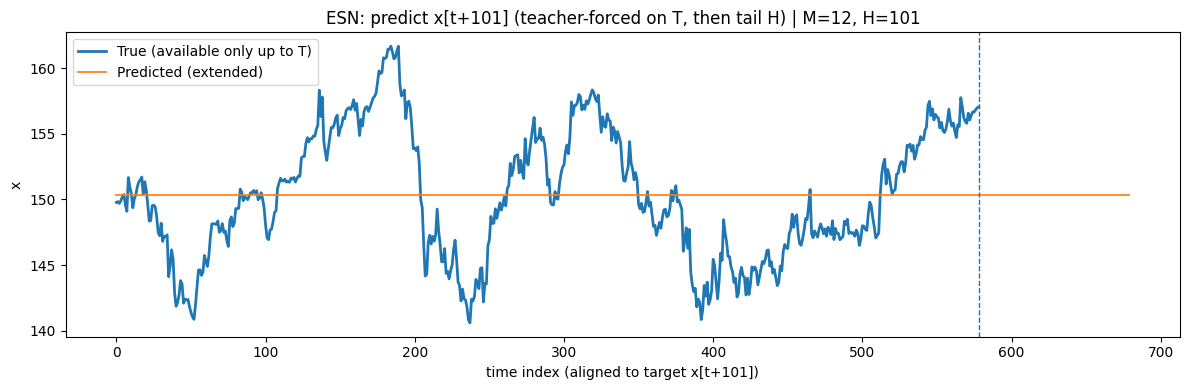

In [ ]:
# x_series_C や x_series_D を入れて実行（あなたの start_t=365 想定）
res = compare_qrc_vs_esn_scalar_extend(
    x_series_C,
    N=1,
    start_t=365,
    T= len(x_series_C) - start_t - 101,
    seed=43,
    H=101,     # ここが「教師なしで延長する点数」
)

[QRC] M=12  (eval on first T only) MSE=20.026780  Corr=0.377137
[ESN] M=12  (eval on first T only) MSE=19.538449  Corr=0.403918
Tail forecast length (no teacher): H=101


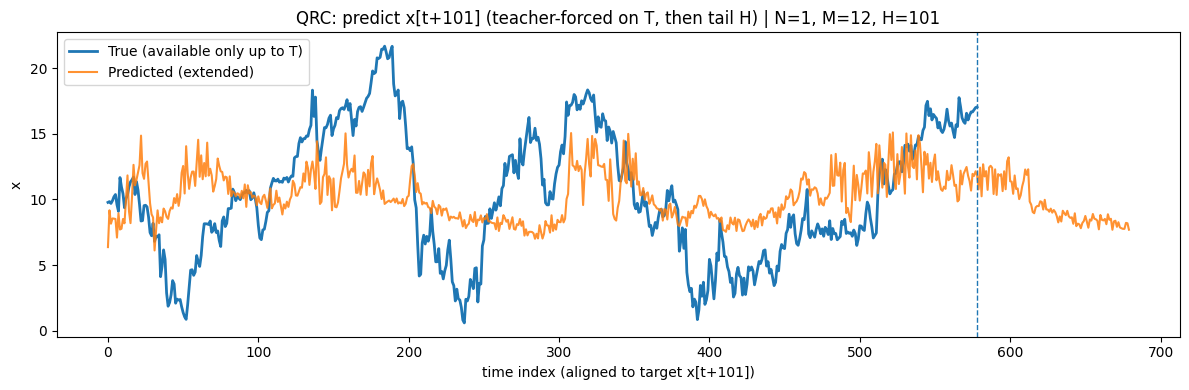

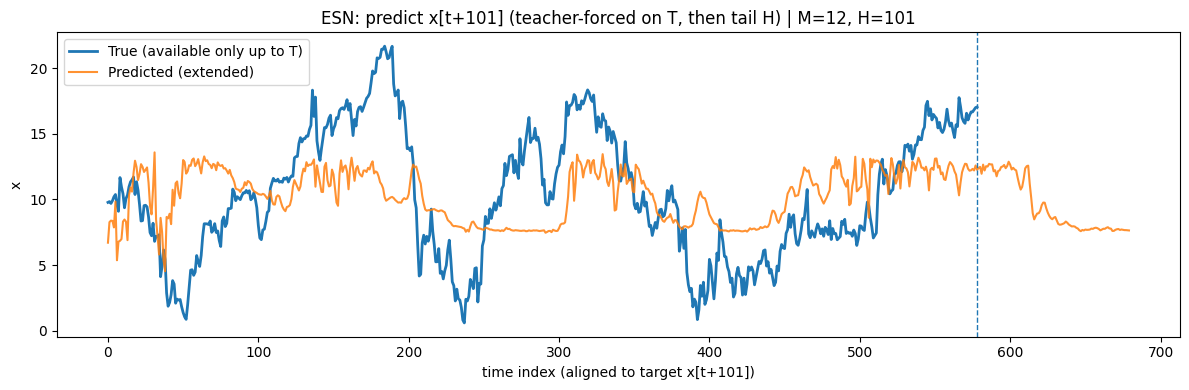

In [ ]:
res = compare_qrc_vs_esn_scalar_extend(
    x_series_D,
    N=1,
    start_t=365,
    T= len(x_series_D) - start_t - 101,
    seed=43,
    H=101,     # ここが「教師なしで延長する点数」
)

[QRC] M=1200  (eval on first T only) MSE=20.188962  Corr=0.368477
[ESN] M=1200  (eval on first T only) MSE=21.916500  Corr=0.248051
Tail forecast length (no teacher): H=101


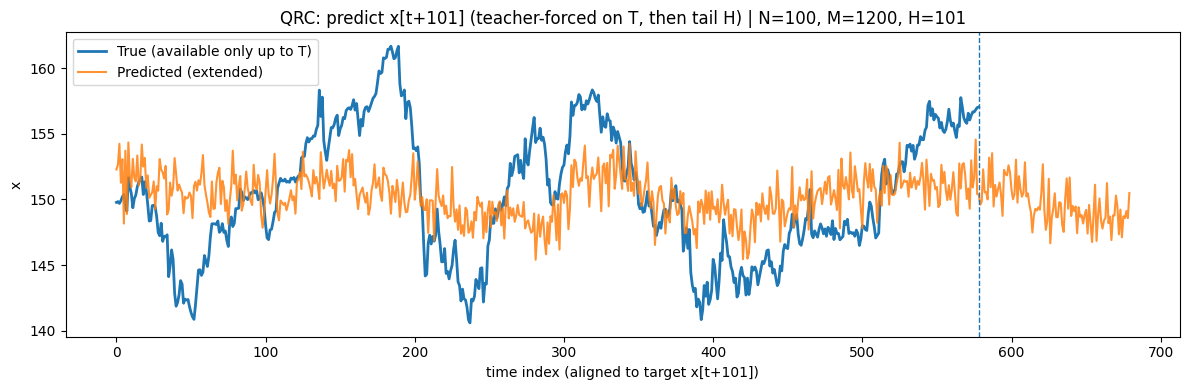

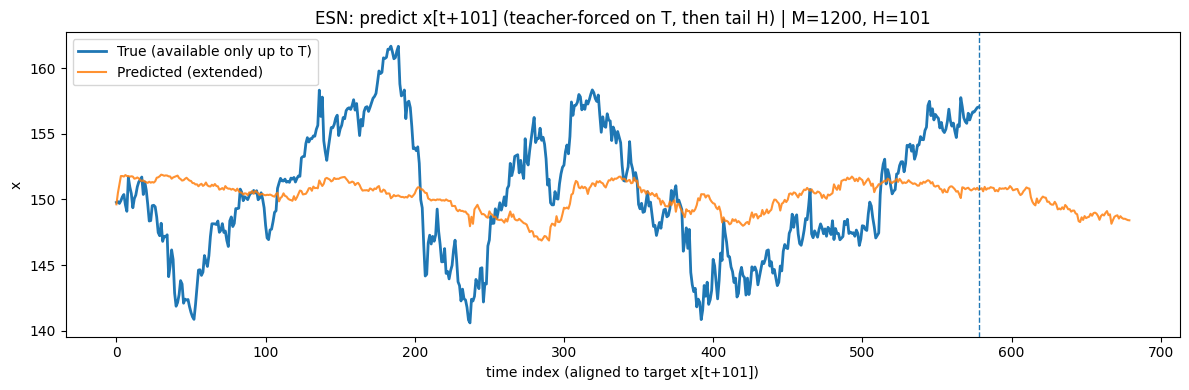

In [ ]:
# x_series_C や x_series_D を入れて実行（あなたの start_t=365 想定）
res = compare_qrc_vs_esn_scalar_extend(
    x_series_C,
    N=100,
    start_t=365,
    T= len(x_series_C) - start_t - 101,
    seed=43,
    H=101,     # ここが「教師なしで延長する点数」
)

[QRC] M=1200  (eval on first T only) MSE=0.032277  Corr=0.999358
[ESN] M=1200  (eval on first T only) MSE=13.131299  Corr=0.663336
Tail forecast length (no teacher): H=101


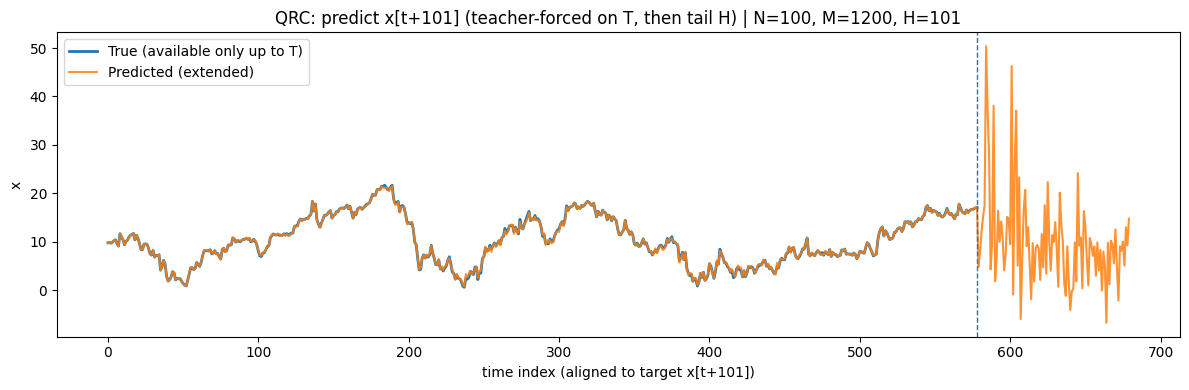

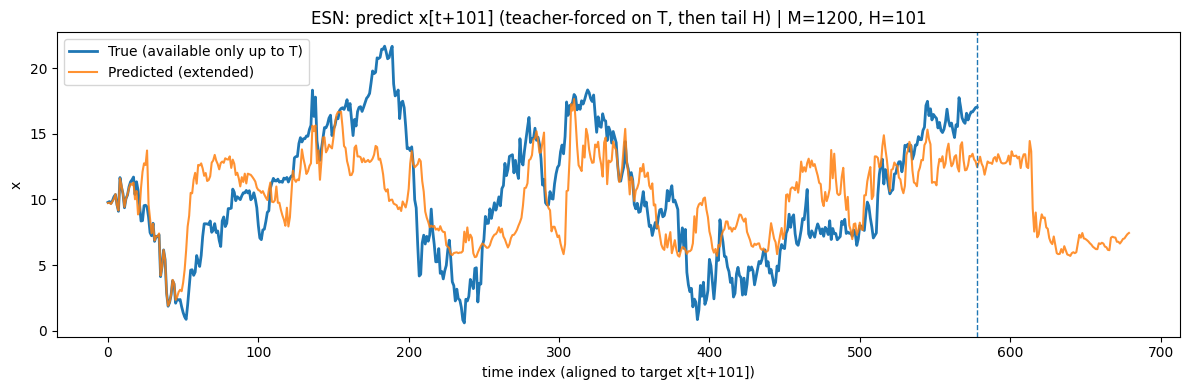

In [ ]:
res = compare_qrc_vs_esn_scalar_extend(
    x_series_D,
    N=100,
    start_t=365,
    T= len(x_series_D) - start_t - 101,
    seed=43,
    H=101,     # ここが「教師なしで延長する点数」
)

[QRC] M=12000  MSE=10.177740  Corr=0.751569
[ESN] M=12000  MSE=21.770288  Corr=0.260178


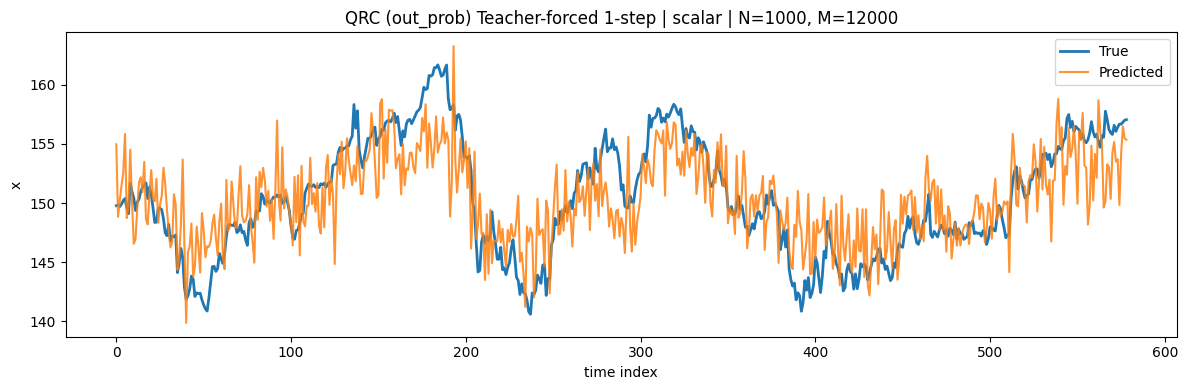

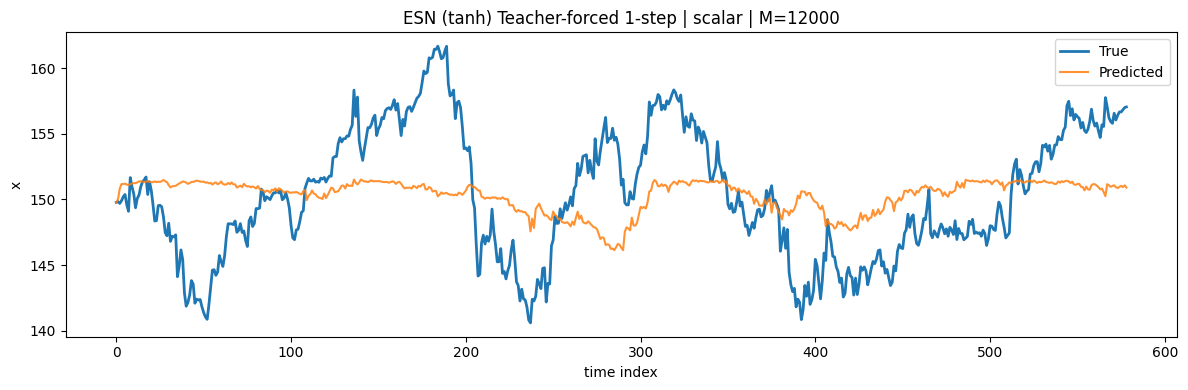

[QRC] M=12000  MSE=0.000001  Corr=1.000000
[ESN] M=12000  MSE=11.374713  Corr=0.717618


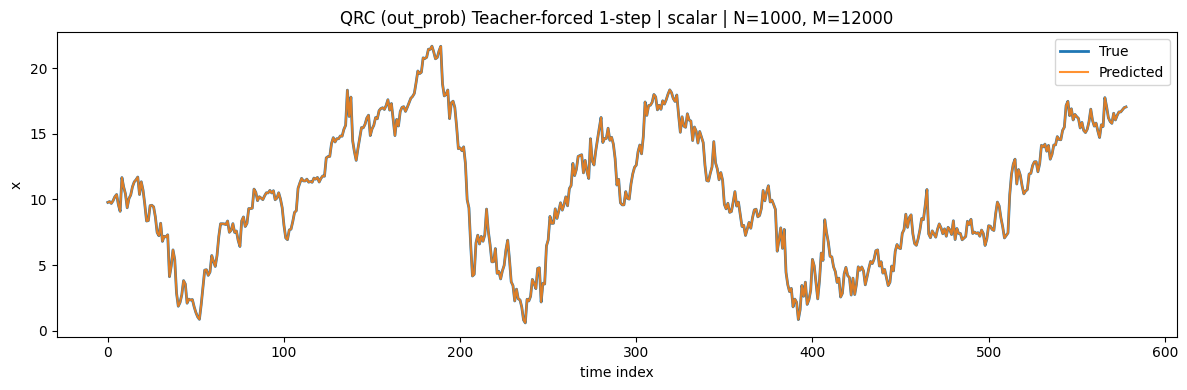

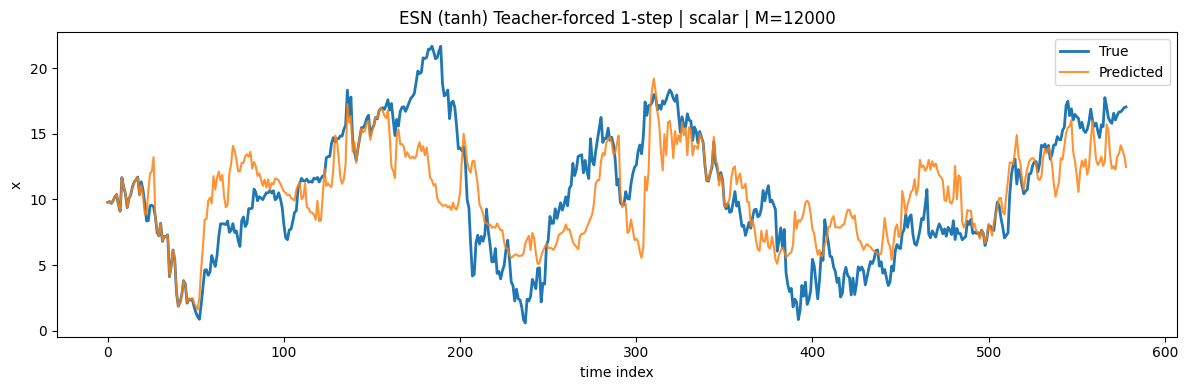

In [ ]:
# ----------------------------
# (A) C列を y(t) として実行
# ----------------------------
res_C = compare_qrc_vs_esn_scalar(
    x_series_C,
    N=1000,
    start_t=start_t,
    T=T_C,
    seed=seed,
    # QRC
    alpha=1.0, beta=0.7, squeeze_r=0.3,
    Win_scale_qrc=1.0,
    carry_state=True,
    ridge=1e-2,
    # ESN
    spectral_radius=0.9,
    input_scale_esn=0.5,
    leak_rate=1.0,
    bias_scale=0.1,
)

# ----------------------------
# (B) D列を y(t) として実行
# ----------------------------
res_D = compare_qrc_vs_esn_scalar(
    x_series_D,
    N=1000,
    start_t=start_t,
    T=T_D,
    seed=seed,
    # QRC
    alpha=1.0, beta=0.7, squeeze_r=0.3,
    Win_scale_qrc=1.0,
    carry_state=True,
    ridge=1e-2,
    # ESN
    spectral_radius=0.9,
    input_scale_esn=0.5,
    leak_rate=1.0,
    bias_scale=0.1,
)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from typing import Tuple, Optional, Dict

# =========================================================
# Trueは最初のTだけ、PredはT+Hまで描く（TrueはH以降NaNで線を切る）
# =========================================================
def plot_true_and_pred_with_tail(y_true_T, y_pred_TplusH, H, title=""):
    y_true_T = np.asarray(y_true_T, float).reshape(-1)
    y_pred_TplusH = np.asarray(y_pred_TplusH, float).reshape(-1)

    T = len(y_true_T)
    if len(y_pred_TplusH) != T + H:
        raise ValueError("length mismatch: y_pred must be T+H")

    # TrueはT以降をNaNにして描画を止める
    y_true_pad = np.concatenate([y_true_T, np.full(H, np.nan)])

    plt.figure(figsize=(12, 4))
    plt.plot(y_true_pad, label="True (available only up to T)", lw=2)
    plt.plot(y_pred_TplusH, label="Predicted (extended)", lw=1.5, alpha=0.85)
    plt.axvline(T - 1, linestyle="--", linewidth=1)  # ここまでが教師あり
    plt.title(title)
    plt.xlabel("time index (aligned to target x[t+101])")
    plt.ylabel("x")
    plt.legend()
    plt.tight_layout()
    plt.show()


# =========================================================
# 「教師ありT点」+「教師なしH点」まで予測する比較関数（スカラー入力）
# ★QRCの状態生成を simulate_qrc_states_sampled01_scalar に差し替え
# ※以下が既に定義済みという前提：
#   - make_scalar_dataset_next  (Y = x[t+101] 版)
#   - simulate_qrc_states_sampled01_scalar   ← これを使う
#   - simulate_esn_states_tanh_scalar
#   - fit_readout_ridge / predict_readout / mse_corr
# =========================================================
def compare_qrc_vs_esn_scalar_extend_sampled01(
    x_series: np.ndarray,
    *,
    N: int = 1,
    start_t: int = 365,
    T: int = 1000,
    seed: int = 43,
    H: int = 101,  # 教師なしで延長したい点数（=101）
    # QRC params
    alpha: float = 1.0,
    beta: float = 0.7,
    squeeze_r: float = 0.3,
    norm_const: float = 1.0,
    sign_mode: str = "plus",
    input_mode: str = "scale",
    Win_scale_qrc: float = 1.0,
    carry_state: bool = True,
    ridge: float = 1e-2,
    # ★追加：QRC measurement (sampled01 + flip)
    shots: int = 1,
    flip_p: float = 0.0,
    # ESN params
    spectral_radius: float = 0.9,
    input_scale_esn: float = 0.5,
    leak_rate: float = 1.0,
    bias_scale: float = 0.1,
):
    # -----------------------------
    # 1) 教師ありデータ（Y = x[t+101]）
    # -----------------------------
    U_train, Y_train = make_scalar_dataset_next(x_series, start_t=start_t, T=T)

    # 教師なしで延長するには入力がもうH点必要（U_extra）
    x = np.asarray(x_series, float).reshape(-1)
    need_len = start_t + T + H  # 入力としてここまで必要
    if need_len > len(x):
        raise ValueError(f"x_series is too short for tail forecast: need len >= {need_len}, got {len(x)}")

    U_all = x[start_t : start_t + T + H]  # (T+H,)
    M = 12 * N

    # -----------------------------
    # 2) QRC: 学習はT点、予測はT+H点
    #    ★simulate_qrc_states_sampled01_scalar を使う
    # -----------------------------
    # 学習用状態列（T点）
    S_qrc_train, _, _, _ = simulate_qrc_states_sampled01_scalar(
        N=N, alpha=alpha, beta=beta, squeeze_r=squeeze_r,
        U=U_train,
        seed=seed,
        norm_const=norm_const,
        sign_mode=sign_mode,
        input_mode=input_mode,
        Win=None,
        Win_scale=Win_scale_qrc,
        carry_state=carry_state,
        shots=shots,
        flip_p=flip_p,
    )
    wq, bq = fit_readout_ridge(S_qrc_train, Y_train, ridge=ridge)

    # 予測用状態列（T+H点）
    S_qrc_all, _, _, _ = simulate_qrc_states_sampled01_scalar(
        N=N, alpha=alpha, beta=beta, squeeze_r=squeeze_r,
        U=U_all,
        seed=seed,
        norm_const=norm_const,
        sign_mode=sign_mode,
        input_mode=input_mode,
        Win=None,
        Win_scale=Win_scale_qrc,
        carry_state=carry_state,
        shots=shots,
        flip_p=flip_p,
    )
    Yhat_qrc_all = predict_readout(S_qrc_all, wq, bq)  # (T+H,)

    # 指標は教師あり部分（最初のT点）のみ
    mse_qrc, corr_qrc = mse_corr(Y_train, Yhat_qrc_all[:T])

    # -----------------------------
    # 3) ESN: 学習はT点、予測はT+H点（従来どおり）
    # -----------------------------
    S_esn_train, _ = simulate_esn_states_tanh_scalar(
        M=M, U=U_train,
        seed=seed,
        spectral_radius=spectral_radius,
        input_scale=input_scale_esn,
        leak_rate=leak_rate,
        bias_scale=bias_scale,
    )
    we, be = fit_readout_ridge(S_esn_train, Y_train, ridge=ridge)

    S_esn_all, _ = simulate_esn_states_tanh_scalar(
        M=M, U=U_all,
        seed=seed,
        spectral_radius=spectral_radius,
        input_scale=input_scale_esn,
        leak_rate=leak_rate,
        bias_scale=bias_scale,
    )
    Yhat_esn_all = predict_readout(S_esn_all, we, be)  # (T+H,)

    mse_esn, corr_esn = mse_corr(Y_train, Yhat_esn_all[:T])

    print(f"[QRC sampled01] M={M} shots={shots} flip={flip_p:.3f}  (eval on first T only) MSE={mse_qrc:.6f}  Corr={corr_qrc:.6f}")
    print(f"[ESN tanh]     M={M}                        (eval on first T only) MSE={mse_esn:.6f}  Corr={corr_esn:.6f}")
    print(f"Tail forecast length (no teacher): H={H}")

    # -----------------------------
    # 4) プロット：TrueはTまで、PredはT+Hまで
    # -----------------------------
    plot_true_and_pred_with_tail(
        Y_train, Yhat_qrc_all, H,
        title=f"QRC sampled01: predict x[t+101] (teacher-forced on T, then tail H) | N={N}, M={M}, shots={shots}, flip={flip_p:.3f}, H={H}"
    )
    plot_true_and_pred_with_tail(
        Y_train, Yhat_esn_all, H,
        title=f"ESN: predict x[t+101] (teacher-forced on T, then tail H) | M={M}, H={H}"
    )

    return {
        "Y_train": Y_train,
        "Yhat_qrc_all": Yhat_qrc_all,  # 長さ T+H（後ろHは教師なし）
        "Yhat_esn_all": Yhat_esn_all,  # 長さ T+H（後ろHは教師なし）
        "metrics_on_T": {
            "qrc": (mse_qrc, corr_qrc),
            "esn": (mse_esn, corr_esn),
        }
    }

[QRC sampled01] M=1200 shots=10 flip=0.075  (eval on first T only) MSE=0.000255  Corr=0.999997
[ESN tanh]     M=1200                        (eval on first T only) MSE=0.877017  Corr=0.983318
Tail forecast length (no teacher): H=101


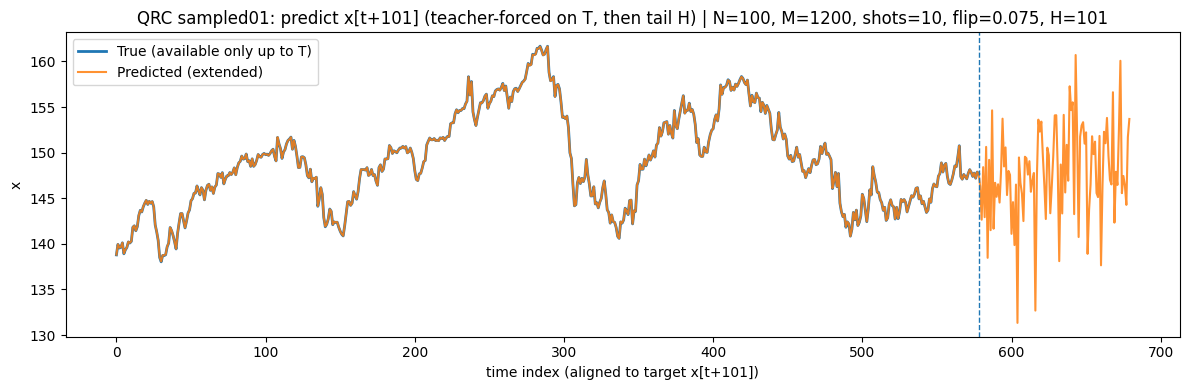

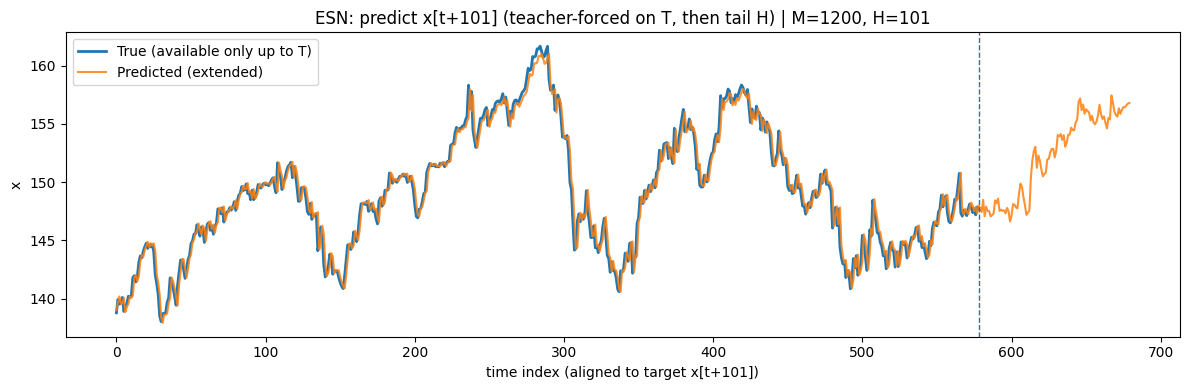

metrics_on_T: {'qrc': (0.00025542984831063186, 0.9999973702748948), 'esn': (0.8770172964460379, 0.9833178758152193)}
len(Y_train)      = 579
len(Yhat_qrc_all) = 680
len(Yhat_esn_all) = 680


In [ ]:
# =========================
# 実行例（出力例つき）
# ※このセルの前に以下が定義済みであること：
#   - make_scalar_dataset_next（Y=x[t+101]版）
#   - simulate_qrc_states_sampled01_scalar（shots/flip対応）
#   - simulate_esn_states_tanh_scalar
#   - fit_readout_ridge / predict_readout / mse_corr
# =========================

# 例：x_series_C を使う（あなたの為替データ C列の系列など）
# x_series_C = ...

res = compare_qrc_vs_esn_scalar_extend_sampled01(
    x_series_C,
    N=100,
    start_t=365,
    T=len(x_series_D) - start_t - 101,     # 例：教師ありは600点だけ評価（短めに）
    H=101,     # 教師なしで101点延長
    seed=43,

    # QRC
    alpha=1.0, beta=0.7, squeeze_r=0.3,
    norm_const=1.0,
    sign_mode="plus",
    input_mode="scale",
    Win_scale_qrc=1.0,
    carry_state=True,
    ridge=1e-2,
    shots=10,      # 例：shots=10
    flip_p=0.075,  # 例：flip 7.5%

    # ESN
    spectral_radius=0.9,
    input_scale_esn=0.5,
    leak_rate=1.0,
    bias_scale=0.1,
)

# 返り値の中身（必要なら）
print("metrics_on_T:", res["metrics_on_T"])
print("len(Y_train)      =", len(res["Y_train"]))
print("len(Yhat_qrc_all) =", len(res["Yhat_qrc_all"]))
print("len(Yhat_esn_all) =", len(res["Yhat_esn_all"]))

[QRC sampled01] M=1200 shots=10 flip=0.075  (eval on first T only) MSE=0.000002  Corr=1.000000
[ESN tanh]     M=1200                        (eval on first T only) MSE=0.620624  Corr=0.988223
Tail forecast length (no teacher): H=101


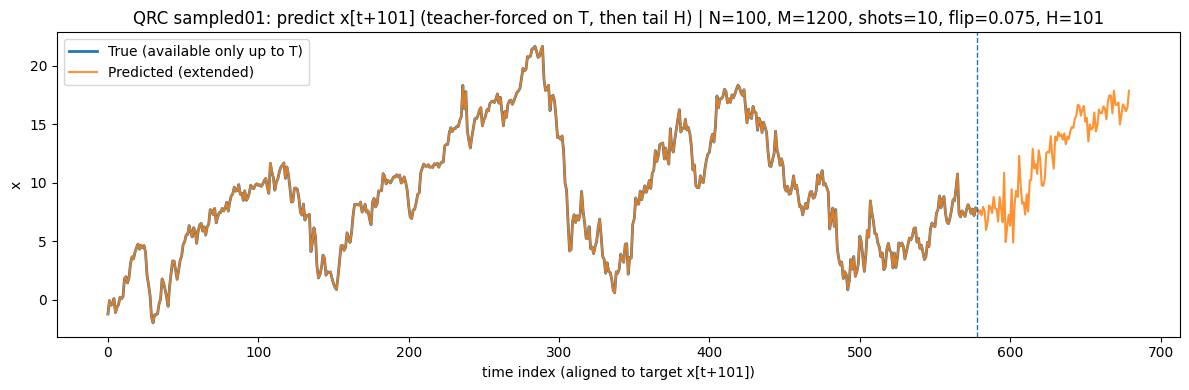

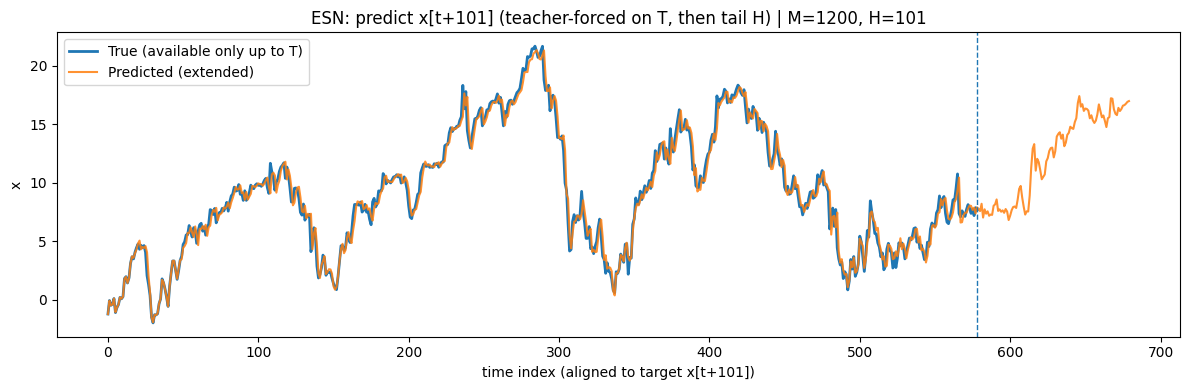

metrics_on_T: {'qrc': (1.979592567274332e-06, 0.9999999633830178), 'esn': (0.6206235309447099, 0.988222754112379)}
len(Y_train)      = 579
len(Yhat_qrc_all) = 680
len(Yhat_esn_all) = 680


In [ ]:
res = compare_qrc_vs_esn_scalar_extend_sampled01(
    x_series_D,
    N=100,
    start_t=365,
    T=len(x_series_D) - start_t - 101,     # 例：教師ありは600点だけ評価（短めに）
    H=101,     # 教師なしで101点延長
    seed=43,

    # QRC
    alpha=1.0, beta=0.7, squeeze_r=0.3,
    norm_const=1.0,
    sign_mode="plus",
    input_mode="scale",
    Win_scale_qrc=1.0,
    carry_state=True,
    ridge=1e-2,
    shots=10,      # 例：shots=10
    flip_p=0.075,  # 例：flip 7.5%

    # ESN
    spectral_radius=0.9,
    input_scale_esn=0.5,
    leak_rate=1.0,
    bias_scale=0.1,
)

# 返り値の中身（必要なら）
print("metrics_on_T:", res["metrics_on_T"])
print("len(Y_train)      =", len(res["Y_train"]))
print("len(Yhat_qrc_all) =", len(res["Yhat_qrc_all"]))
print("len(Yhat_esn_all) =", len(res["Yhat_esn_all"]))

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from typing import Tuple, Optional, Dict

def compare_qrc_vs_esn_scalar_extend_sampled01_replaced(
    x_series: np.ndarray,
    *,
    N: int = 1,
    start_t: int = 365,
    # ★ここがポイント：Tは「教師あり学習に使う点数」、T_totalは「入力として与える総点数」
    T: int = 500,            # = T_train（例：0..499）
    T_total: int = 600,      # = 入力として与える総点数（例：0..599）  ※T_total >= T
    lookahead: int = 101,    # y(t)=x(t+101)
    seed: int = 43,

    # QRC params
    alpha: float = 1.0,
    beta: float = 0.7,
    squeeze_r: float = 0.3,
    norm_const: float = 1.0,
    sign_mode: str = "plus",
    input_mode: str = "scale",
    Win_scale_qrc: float = 1.0,
    carry_state: bool = True,
    ridge: float = 1e-2,

    # QRC measurement (sampled01 + flip)
    shots: int = 1,
    flip_p: float = 0.0,

    # ESN params
    spectral_radius: float = 0.9,
    input_scale_esn: float = 0.5,
    leak_rate: float = 1.0,
    bias_scale: float = 0.1,
):
    """
    目的：
      u(t)=x(t) を start_t..start_t+T_total-1 までだけ与える（それ以上は入力に使わない）
      教師あり学習は t=start_t..start_t+T-1 のみ（T点）
      その後は同じ入力列の後半（t=start_t+T..start_t+T_total-1）に対して
      教師なし（ラベル無し）で y(t)=x(t+lookahead) を推定する（H_tail=T_total-T点）

    返り値：
      Y_train: 学習ラベル（長さT）
      Yhat_*_all: 予測（長さT_total）  ※末尾 H_tail 点が「教師なし予測区間」
    """

    # -----------------------------
    # 0) 前提チェック
    # -----------------------------
    if T_total < T:
        raise ValueError(f"need T_total >= T (got T_total={T_total}, T={T})")

    x = np.asarray(x_series, float).reshape(-1)

    # 入力として必要：x[start_t : start_t+T_total]
    need_len_inputs = start_t + T_total
    if need_len_inputs > len(x):
        raise ValueError(f"x_series is too short for inputs: need len >= {need_len_inputs}, got {len(x)}")

    # 学習ラベルとして必要：x[start_t+lookahead : start_t+lookahead+T]
    need_len_labels = start_t + lookahead + T
    if need_len_labels > len(x):
        raise ValueError(f"x_series is too short for train labels: need len >= {need_len_labels}, got {len(x)}")

    # -----------------------------
    # 1) 教師ありデータ（T点）：Y = x[t+lookahead]
    #    ※ make_scalar_dataset_next が +101 固定の場合でも、
    #      lookahead=101 で使う限り整合します
    # -----------------------------
    # 互換性のため、従来関数を呼ぶ（中が +101 固定なら lookahead=101 で使ってください）
    U_train, Y_train = make_scalar_dataset_next(x_series, start_t=start_t, T=T)  # (T,), (T,)

    # 予測したい入力全体：t=start_t..start_t+T_total-1 のみ（入力はここまで）
    U_all = x[start_t : start_t + T_total]  # (T_total,)

    H_tail = T_total - T
    M = 12 * N

    # -----------------------------
    # 2) QRC sampled01: 学習はT点、予測はT_total点
    # -----------------------------
    S_qrc_train, _, _, _ = simulate_qrc_states_sampled01_scalar(
        N=N, alpha=alpha, beta=beta, squeeze_r=squeeze_r,
        U=U_train,
        seed=seed,
        norm_const=norm_const,
        sign_mode=sign_mode,
        input_mode=input_mode,
        Win=None,
        Win_scale=Win_scale_qrc,
        carry_state=carry_state,
        shots=shots,
        flip_p=flip_p,
    )
    wq, bq = fit_readout_ridge(S_qrc_train, Y_train, ridge=ridge)

    S_qrc_all, _, _, _ = simulate_qrc_states_sampled01_scalar(
        N=N, alpha=alpha, beta=beta, squeeze_r=squeeze_r,
        U=U_all,   # ★入力は start_t..start_t+T_total-1 までしか使わない
        seed=seed,
        norm_const=norm_const,
        sign_mode=sign_mode,
        input_mode=input_mode,
        Win=None,
        Win_scale=Win_scale_qrc,
        carry_state=carry_state,
        shots=shots,
        flip_p=flip_p,
    )
    Yhat_qrc_all = predict_readout(S_qrc_all, wq, bq)  # (T_total,)

    # 指標は教師あり部分（最初のT点）のみ
    mse_qrc, corr_qrc = mse_corr(Y_train, Yhat_qrc_all[:T])

    # -----------------------------
    # 3) ESN tanh: 学習はT点、予測はT_total点
    # -----------------------------
    S_esn_train, _ = simulate_esn_states_tanh_scalar(
        M=M, U=U_train,
        seed=seed,
        spectral_radius=spectral_radius,
        input_scale=input_scale_esn,
        leak_rate=leak_rate,
        bias_scale=bias_scale,
    )
    we, be = fit_readout_ridge(S_esn_train, Y_train, ridge=ridge)

    S_esn_all, _ = simulate_esn_states_tanh_scalar(
        M=M, U=U_all,  # ★入力は start_t..start_t+T_total-1 まで
        seed=seed,
        spectral_radius=spectral_radius,
        input_scale=input_scale_esn,
        leak_rate=leak_rate,
        bias_scale=bias_scale,
    )
    Yhat_esn_all = predict_readout(S_esn_all, we, be)  # (T_total,)

    mse_esn, corr_esn = mse_corr(Y_train, Yhat_esn_all[:T])

    print(f"[QRC sampled01] M={M} shots={shots} flip={flip_p:.3f}  (eval on first T={T}) MSE={mse_qrc:.6f}  Corr={corr_qrc:.6f}")
    print(f"[ESN tanh]     M={M}                        (eval on first T={T}) MSE={mse_esn:.6f}  Corr={corr_esn:.6f}")
    print(f"Tail prediction (no labels used in training): H_tail={H_tail}  (t = {T}..{T_total-1})")
    print(f"Predicts x(t+{lookahead}) for t in [{start_t}, {start_t+T_total-1}] -> x indices [{start_t+lookahead}, {start_t+T_total-1+lookahead}]")

    # -----------------------------
    # 4) プロット：TrueはTまで、PredはT_totalまで
    # -----------------------------
    plot_true_and_pred_with_tail(
        Y_train, Yhat_qrc_all, H_tail,
        title=f"QRC sampled01: predict x[t+{lookahead}] (train T={T}, then tail={H_tail}) | N={N}, M={M}, shots={shots}, flip={flip_p:.3f}"
    )
    plot_true_and_pred_with_tail(
        Y_train, Yhat_esn_all, H_tail,
        title=f"ESN tanh: predict x[t+{lookahead}] (train T={T}, then tail={H_tail}) | M={M}"
    )

    return {
        "Y_train": Y_train,
        "Yhat_qrc_all": Yhat_qrc_all,  # 長さ T_total（後ろH_tailが教師なし）
        "Yhat_esn_all": Yhat_esn_all,  # 長さ T_total（後ろH_tailが教師なし）
        "metrics_on_T": {
            "qrc": (mse_qrc, corr_qrc),
            "esn": (mse_esn, corr_esn),
        },
        "meta": {
            "start_t": start_t,
            "T_train": T,
            "T_total": T_total,
            "H_tail": H_tail,
            "lookahead": lookahead,
        }
    }

[QRC sampled01] M=1200 shots=10 flip=0.075  (eval on first T=500) MSE=0.000002  Corr=1.000000
[ESN tanh]     M=1200                        (eval on first T=500) MSE=0.521209  Corr=0.997340
Tail prediction (no labels used in training): H_tail=100  (t = 500..599)
Predicts x(t+101) for t in [0, 599] -> x indices [101, 700]


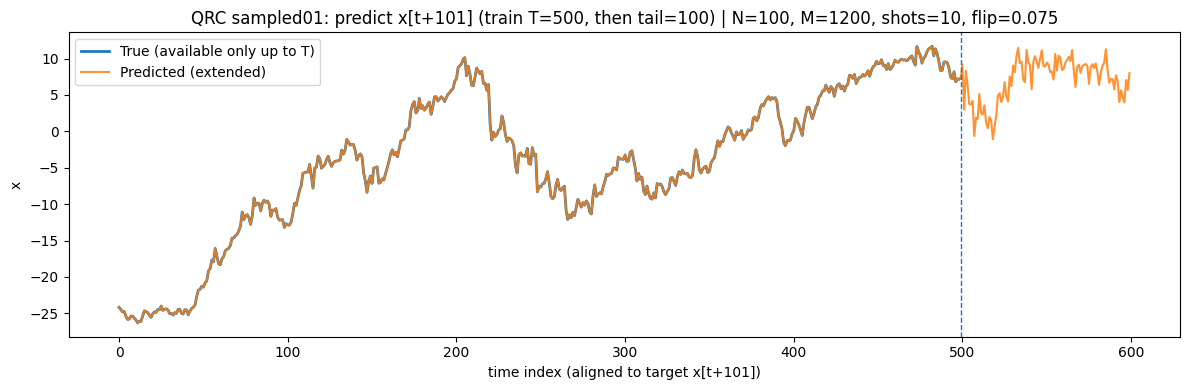

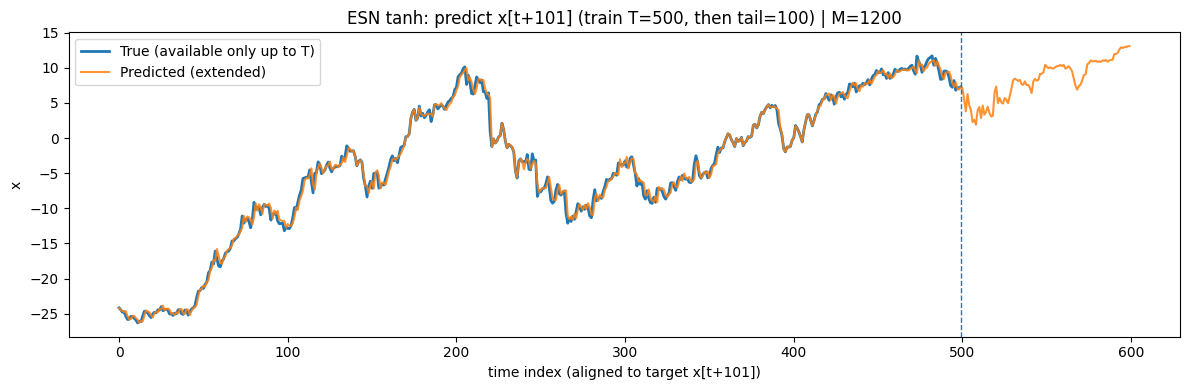

In [ ]:
res = compare_qrc_vs_esn_scalar_extend_sampled01_replaced(
    x_series_D,
    start_t=0,
    T=500,
    T_total=600,
    lookahead=101,
    N=100,
    shots=10,
    flip_p=0.075
)

In [ ]:
import numpy as np

def compare_qrc_vs_esn_scalar_extend_sampled01_replaced(
    x_series: np.ndarray,
    *,
    N: int = 1,
    start_t: int = 0,

    # ★ここが変更点：
    # T_total = 実際に与える入力 u(t)=x(t) の点数（例：500点 = t=0..499）
    # H_tail  = 入力を与えていない先（疑似入力で延長したい点数。例：100点で x(601)..x(700)）
    T_total: int = 500,
    H_tail: int = 100,

    # y(t)=x(t+lookahead)
    lookahead: int = 101,

    seed: int = 43,

    # QRC params
    alpha: float = 1.0,
    beta: float = 0.7,
    squeeze_r: float = 0.3,
    norm_const: float = 1.0,
    sign_mode: str = "plus",
    input_mode: str = "scale",
    Win_scale_qrc: float = 1.0,
    carry_state: bool = True,
    ridge: float = 1e-2,

    # QRC measurement (sampled01 + flip)
    shots: int = 1,
    flip_p: float = 0.0,

    # ESN params
    spectral_radius: float = 0.9,
    input_scale_esn: float = 0.5,
    leak_rate: float = 1.0,
    bias_scale: float = 0.1,
):
    """
    実入力は t=start_t..start_t+T_total-1 までしか与えない（例：0..499）。
    学習はその全区間（T_total点）で y(t)=x(t+lookahead) を回帰。
    ただし t>=T_total の入力 u(t)=x(t) は未知なので、
      u(t) := 予測で得た \hat{x}(t)（= t-lookahead 時点の出力）で代用して H_tail 点だけ延長。
    これにより、t=T_total..T_total+H_tail-1 の出力として x(t+lookahead) を推定できる。
    """

    # -----------------------------
    # 前提チェック
    # -----------------------------
    if H_tail < 0:
        raise ValueError("H_tail must be >= 0")
    if T_total <= 0:
        raise ValueError("T_total must be >= 1")
    if lookahead <= 0:
        raise ValueError("lookahead must be >= 1")

    # この「一発延長」が安全にできる条件（自己参照なし）
    if H_tail > lookahead:
        raise ValueError(
            f"H_tail={H_tail} is > lookahead={lookahead}. "
            "This requires recursive rollout (inputs depend on outputs that depend on those inputs)."
        )

    x = np.asarray(x_series, float).reshape(-1)

    # 入力として必要: x[start_t : start_t+T_total]
    need_len_inputs = start_t + T_total
    if need_len_inputs > len(x):
        raise ValueError(f"x_series too short for inputs: need len >= {need_len_inputs}, got {len(x)}")

    # 学習ラベルとして必要: x[start_t+lookahead : start_t+lookahead+T_total]
    need_len_labels = start_t + lookahead + T_total
    if need_len_labels > len(x):
        raise ValueError(f"x_series too short for train labels: need len >= {need_len_labels}, got {len(x)}")

    # -----------------------------
    # 1) 教師ありデータ（学習は T_total 点）
    # -----------------------------
    U_known = x[start_t : start_t + T_total]  # (T_total,)  実入力はここまで
    Y_train = x[start_t + lookahead : start_t + lookahead + T_total]  # (T_total,)  x(t+101)

    M = 12 * N

    # =========================================================
    # QRC: まず実入力だけで学習→その出力で疑似入力を作って延長
    # =========================================================
    S_qrc_known, _, _, _ = simulate_qrc_states_sampled01_scalar(
        N=N, alpha=alpha, beta=beta, squeeze_r=squeeze_r,
        U=U_known,
        seed=seed,
        norm_const=norm_const,
        sign_mode=sign_mode,
        input_mode=input_mode,
        Win=None,
        Win_scale=Win_scale_qrc,
        carry_state=carry_state,
        shots=shots,
        flip_p=flip_p,
    )
    wq, bq = fit_readout_ridge(S_qrc_known, Y_train, ridge=ridge)

    # 実入力区間の予測（ここから x_hat(t) を取り出して疑似入力に使う）
    Yhat_qrc_known = predict_readout(S_qrc_known, wq, bq)  # (T_total,)

    # 疑似入力 u(t)=x(t) の代用：
    # t = T_total .. T_total+H_tail-1 に対し、x(t) は (t-lookahead) 時点の出力で手に入る
    # indices = (T_total - lookahead) .. (T_total - lookahead + H_tail - 1)
    idx0 = T_total - lookahead
    idx1 = idx0 + H_tail
    if idx0 < 0:
        raise ValueError(
            f"T_total={T_total} is smaller than lookahead={lookahead}; "
            "cannot build pseudo-inputs without earlier predictions."
        )

    U_tail_qrc = Yhat_qrc_known[idx0:idx1]  # (H_tail,)
    U_ext_qrc = np.concatenate([U_known, U_tail_qrc])     # (T_total+H_tail,)

    # 延長入力列で状態列を作り、出力（長さ T_total+H_tail）を得る
    S_qrc_all, _, _, _ = simulate_qrc_states_sampled01_scalar(
        N=N, alpha=alpha, beta=beta, squeeze_r=squeeze_r,
        U=U_ext_qrc,
        seed=seed,
        norm_const=norm_const,
        sign_mode=sign_mode,
        input_mode=input_mode,
        Win=None,
        Win_scale=Win_scale_qrc,
        carry_state=carry_state,
        shots=shots,
        flip_p=flip_p,
    )
    Yhat_qrc_all = predict_readout(S_qrc_all, wq, bq)  # (T_total+H_tail,)

    mse_qrc, corr_qrc = mse_corr(Y_train, Yhat_qrc_all[:T_total])

    # =========================================================
    # ESN: 同様に「自分の予測」で疑似入力を作って延長
    # =========================================================
    S_esn_known, _ = simulate_esn_states_tanh_scalar(
        M=M, U=U_known,
        seed=seed,
        spectral_radius=spectral_radius,
        input_scale=input_scale_esn,
        leak_rate=leak_rate,
        bias_scale=bias_scale,
    )
    we, be = fit_readout_ridge(S_esn_known, Y_train, ridge=ridge)
    Yhat_esn_known = predict_readout(S_esn_known, we, be)  # (T_total,)

    U_tail_esn = Yhat_esn_known[idx0:idx1]               # (H_tail,)
    U_ext_esn = np.concatenate([U_known, U_tail_esn])    # (T_total+H_tail,)

    S_esn_all, _ = simulate_esn_states_tanh_scalar(
        M=M, U=U_ext_esn,
        seed=seed,
        spectral_radius=spectral_radius,
        input_scale=input_scale_esn,
        leak_rate=leak_rate,
        bias_scale=bias_scale,
    )
    Yhat_esn_all = predict_readout(S_esn_all, we, be)  # (T_total+H_tail,)

    mse_esn, corr_esn = mse_corr(Y_train, Yhat_esn_all[:T_total])

    # -----------------------------
    # 出力と可視化
    # -----------------------------
    print(f"[QRC sampled01] M={M} shots={shots} flip={flip_p:.3f}  (eval on first T_total={T_total}) MSE={mse_qrc:.6f}  Corr={corr_qrc:.6f}")
    print(f"[ESN tanh]     M={M}                        (eval on first T_total={T_total}) MSE={mse_esn:.6f}  Corr={corr_esn:.6f}")
    print(f"Pseudo-input tail: H_tail={H_tail} (inputs beyond T_total are model-predicted x(t))")
    print(f"Predicted targets cover x(t+{lookahead}) for t in [{start_t}, {start_t+T_total+H_tail-1}]")

    # True は学習ラベル（T_total点）だけ、Pred は T_total+H_tail 点まで
    plot_true_and_pred_with_tail(
        Y_train, Yhat_qrc_all, H_tail,
        title=f"QRC sampled01: real inputs {T_total} + pseudo tail {H_tail} | lookahead={lookahead}, N={N}, M={M}, shots={shots}, flip={flip_p:.3f}"
    )
    plot_true_and_pred_with_tail(
        Y_train, Yhat_esn_all, H_tail,
        title=f"ESN tanh: real inputs {T_total} + pseudo tail {H_tail} | lookahead={lookahead}, M={M}"
    )

    return {
        "Y_train": Y_train,                 # 長さ T_total（教師あり）
        "Yhat_qrc_all": Yhat_qrc_all,       # 長さ T_total+H_tail（末尾H_tailが「入力も疑似」）
        "Yhat_esn_all": Yhat_esn_all,
        "metrics_on_T_total": {
            "qrc": (mse_qrc, corr_qrc),
            "esn": (mse_esn, corr_esn),
        },
        "meta": {
            "start_t": start_t,
            "T_total_real_inputs": T_total,
            "H_tail_pseudo_inputs": H_tail,
            "lookahead": lookahead,
            "note": "Tail uses pseudo-inputs u(t)=x_hat(t)=y_hat(t-lookahead). Valid without recursion when H_tail <= lookahead."
        }
    }

<>:45: SyntaxWarning: invalid escape sequence '\h'
<>:45: SyntaxWarning: invalid escape sequence '\h'
/tmp/ipython-input-3040980952.py:45: SyntaxWarning: invalid escape sequence '\h'
  u(t) := 予測で得た \hat{x}(t)（= t-lookahead 時点の出力）で代用して H_tail 点だけ延長。


[QRC sampled01] M=1200 shots=10 flip=0.075  (eval on first T_total=500) MSE=0.000031  Corr=1.000000
[ESN tanh]     M=1200                        (eval on first T_total=500) MSE=16.200008  Corr=0.815562
Pseudo-input tail: H_tail=100 (inputs beyond T_total are model-predicted x(t))
Predicted targets cover x(t+101) for t in [0, 599]


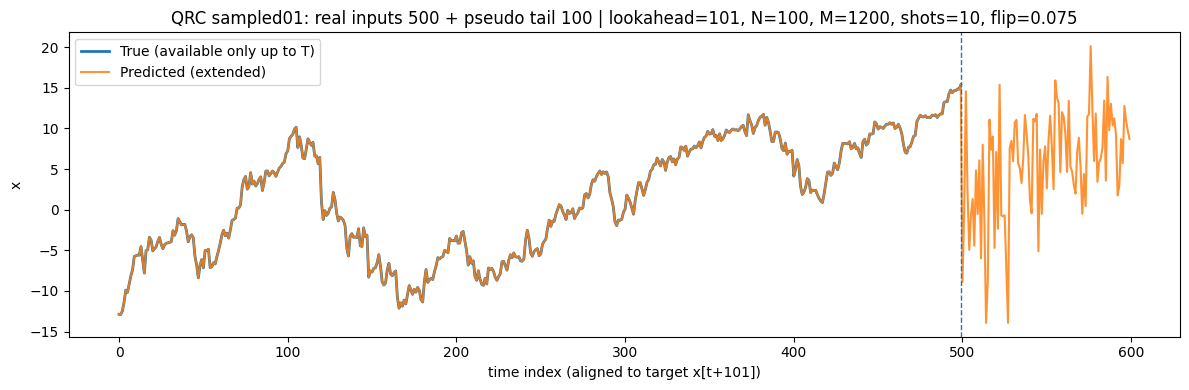

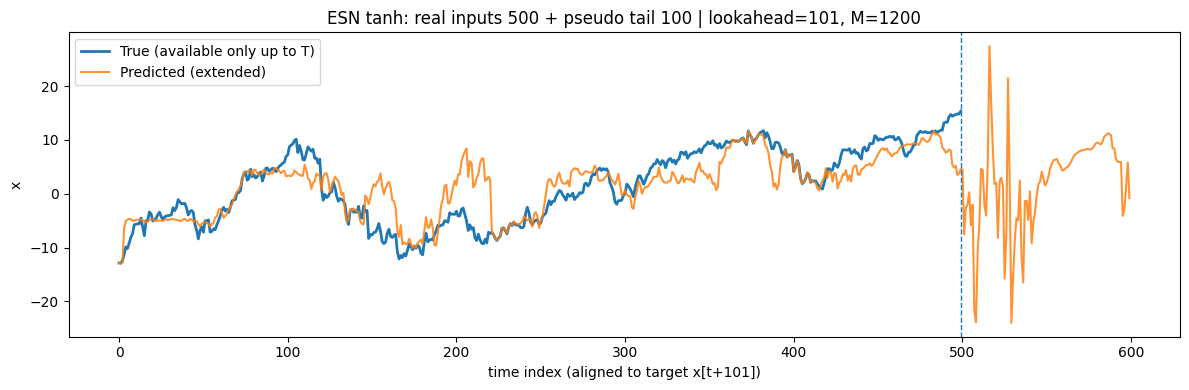

In [ ]:
res = compare_qrc_vs_esn_scalar_extend_sampled01_replaced(
    x_series_D,
    start_t=0,
    T_total=500,
    H_tail=100,
    lookahead=101,
    N=100,
    shots=10,
    flip_p=0.075
)

[QRC sampled01] M=1200 shots=10 flip=0.000  (eval on first T_total=500) MSE=0.000154  Corr=0.999999
[ESN tanh]     M=1200                        (eval on first T_total=500) MSE=16.200008  Corr=0.815562
Pseudo-input tail: H_tail=100 (inputs beyond T_total are model-predicted x(t))
Predicted targets cover x(t+101) for t in [0, 599]


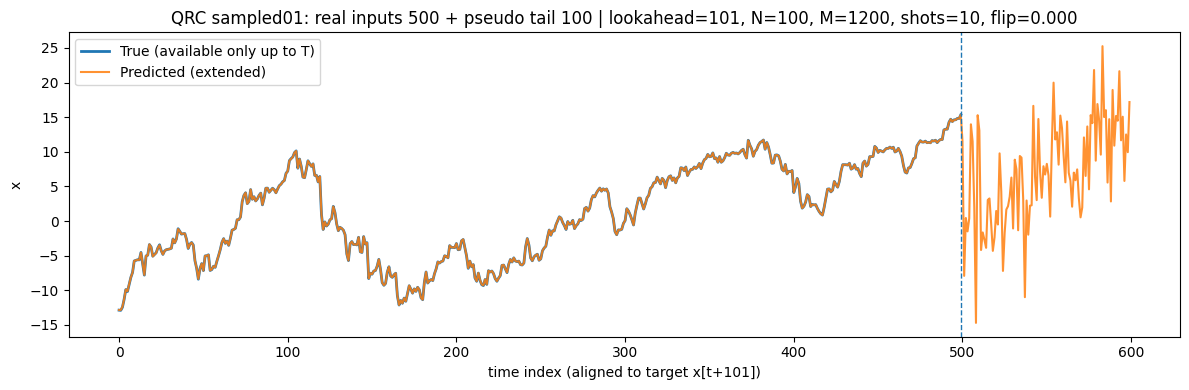

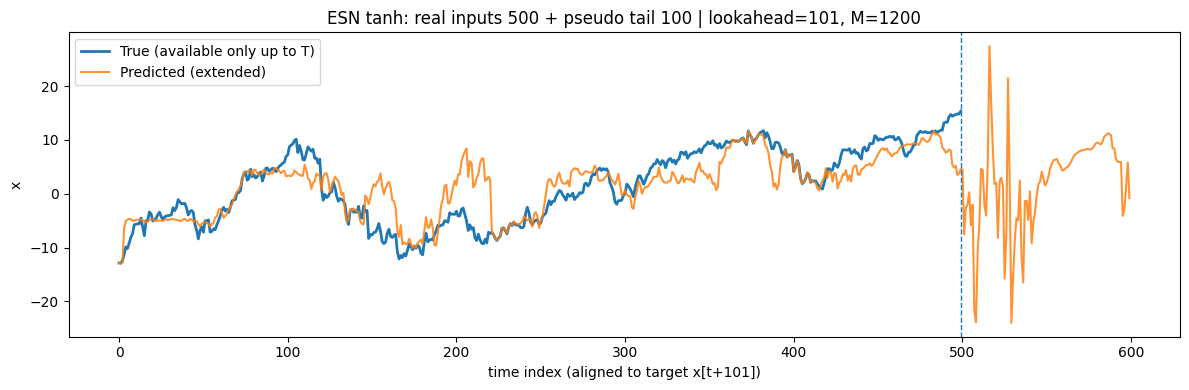

In [ ]:
res = compare_qrc_vs_esn_scalar_extend_sampled01_replaced(
    x_series_D,
    start_t=0,
    T_total=500,
    H_tail=100,
    lookahead=101,
    N=100,
    shots=10,
    flip_p=0.0
)

[QRC sampled01] M=120 shots=10 flip=0.075  (eval on first T_total=500) MSE=27.982566  Corr=0.645279
[ESN tanh]     M=120                        (eval on first T_total=500) MSE=25.674037  Corr=0.683190
Pseudo-input tail: H_tail=100 (inputs beyond T_total are model-predicted x(t))
Predicted targets cover x(t+101) for t in [0, 599]


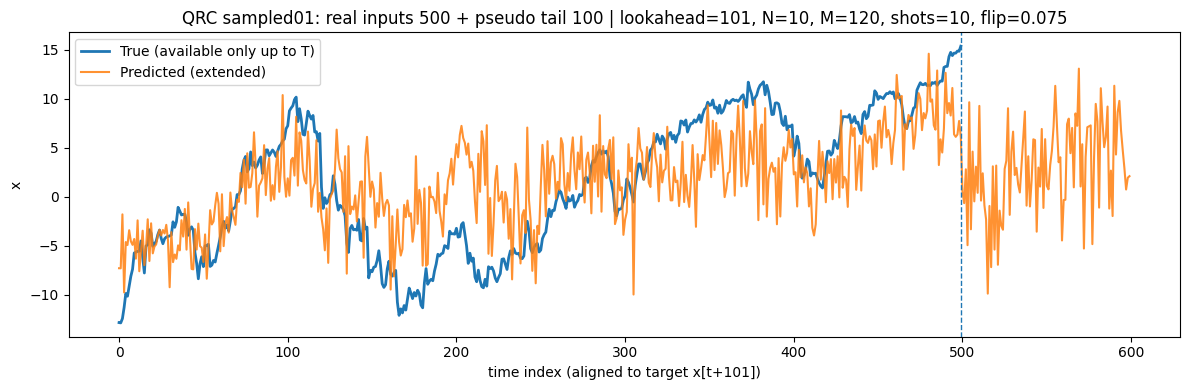

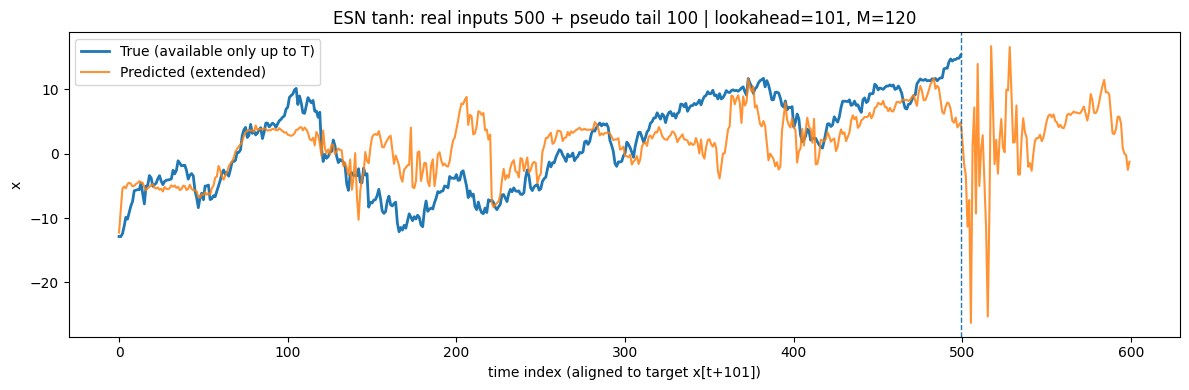

In [ ]:
res = compare_qrc_vs_esn_scalar_extend_sampled01_replaced(
    x_series_D,
    start_t=0,
    T_total=500,
    H_tail=100,
    lookahead=101,
    N=10,
    shots=10,
    flip_p=0.075
)

[QRC sampled01] M=1200 shots=100 flip=0.075  (eval on first T_total=500) MSE=0.000350  Corr=0.999997
[ESN tanh]     M=1200                        (eval on first T_total=500) MSE=16.200008  Corr=0.815562
Pseudo-input tail: H_tail=100 (inputs beyond T_total are model-predicted x(t))
Predicted targets cover x(t+101) for t in [0, 599]


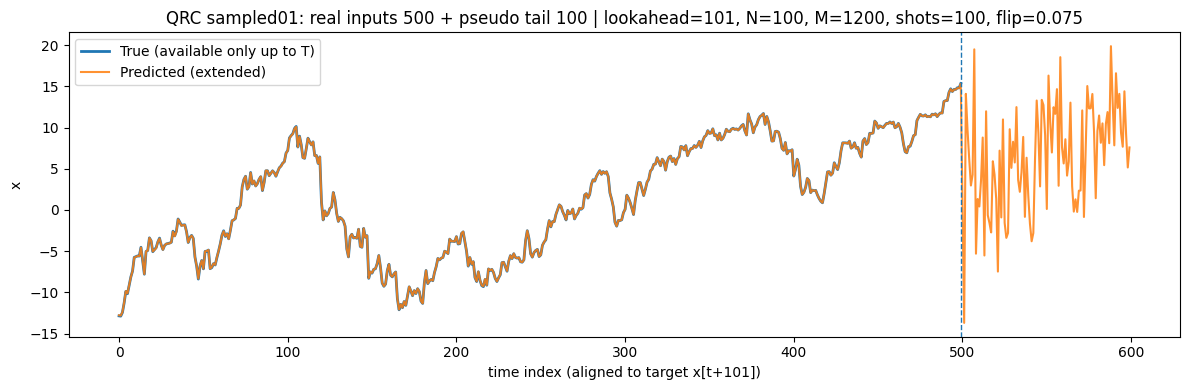

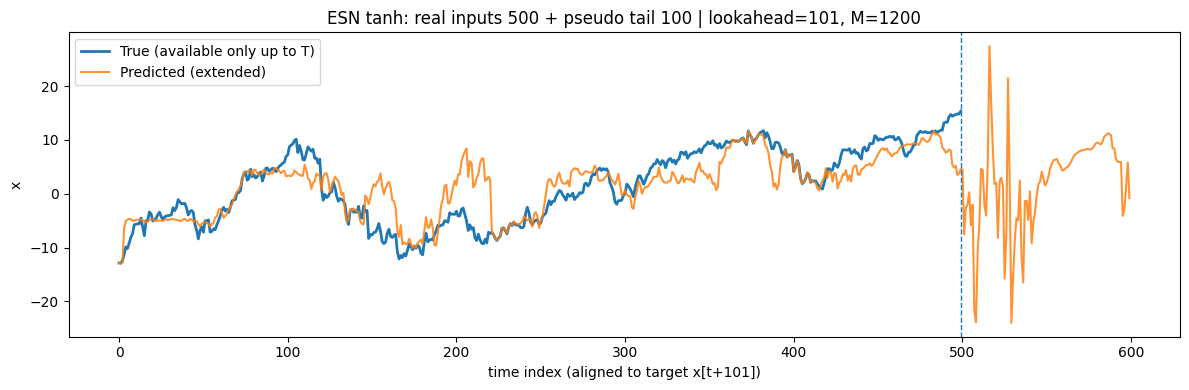

In [ ]:
res = compare_qrc_vs_esn_scalar_extend_sampled01_replaced(
    x_series_D,
    start_t=0,
    T_total=500,
    H_tail=100,
    lookahead=101,
    N=100,
    shots=100,
    flip_p=0.075
)

[QRC sampled01] M=12000 shots=10 flip=0.075  (eval on first T_total=500) MSE=0.000000  Corr=1.000000
[ESN tanh]     M=12000                        (eval on first T_total=500) MSE=10.945498  Corr=0.880255
Pseudo-input tail: H_tail=100 (inputs beyond T_total are model-predicted x(t))
Predicted targets cover x(t+101) for t in [0, 599]


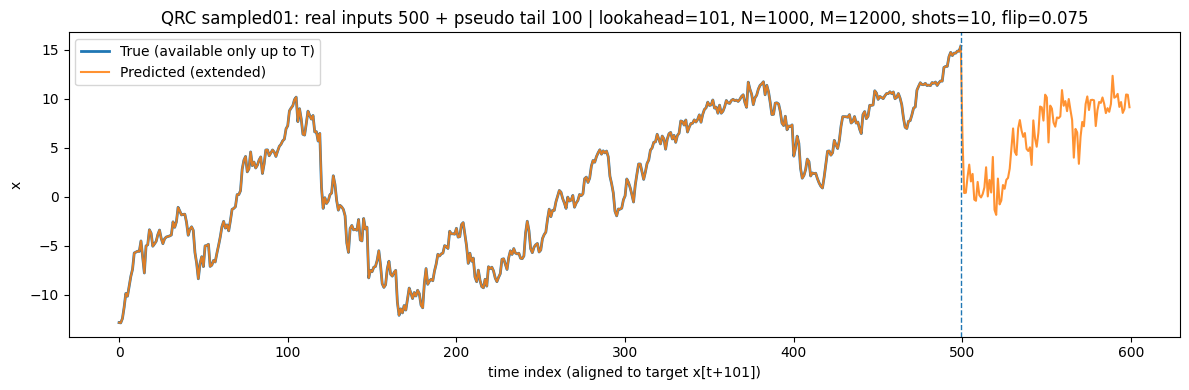

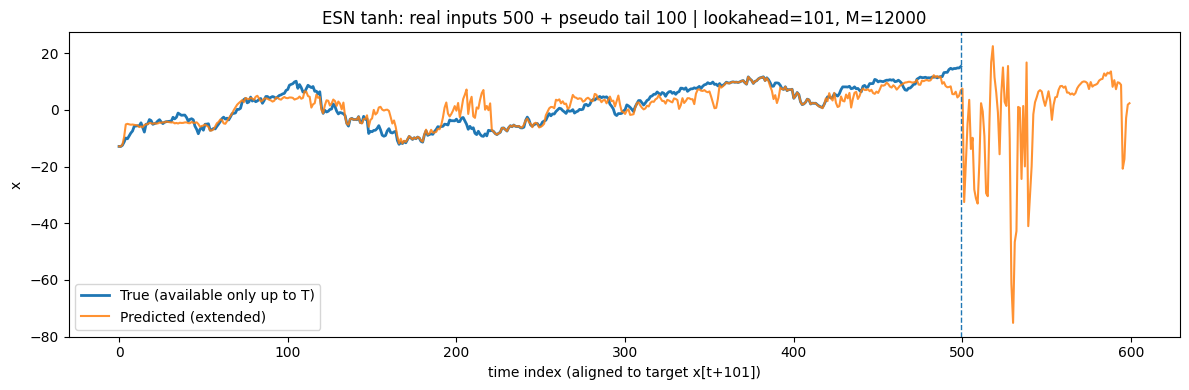

In [ ]:
res = compare_qrc_vs_esn_scalar_extend_sampled01_replaced(
    x_series_D,
    start_t=0,
    T_total=500,
    H_tail=100,
    lookahead=101,
    N=1000,
    shots=10,
    flip_p=0.075
)

[QRC sampled01] M=1200 shots=10 flip=0.075  (eval on first T_total=944) MSE=0.001024  Corr=0.999992
[ESN tanh]     M=1200                        (eval on first T_total=944) MSE=22.710808  Corr=0.787600
Pseudo-input tail: H_tail=100 (inputs beyond T_total are model-predicted x(t))
Predicted targets cover x(t+101) for t in [0, 1043]


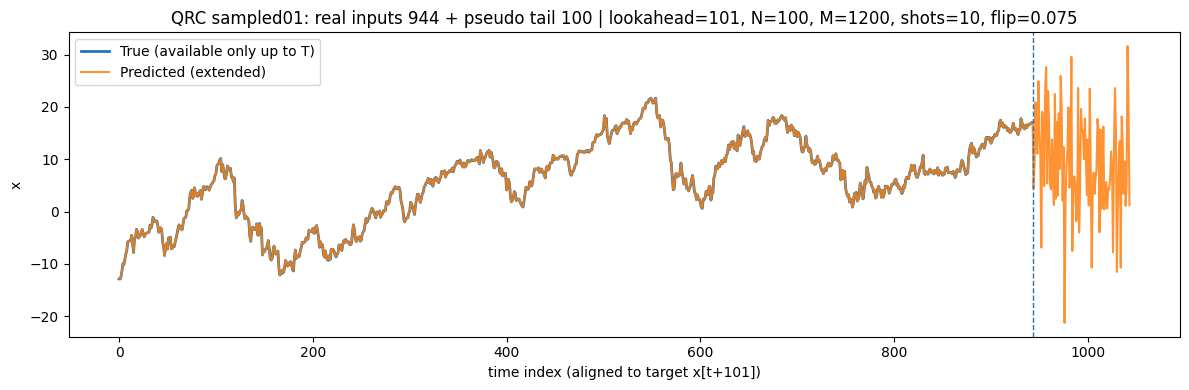

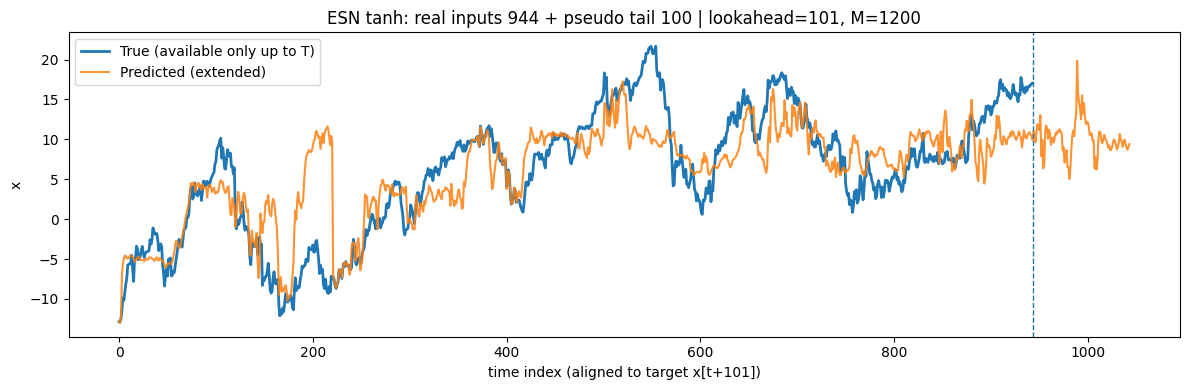

In [ ]:
res = compare_qrc_vs_esn_scalar_extend_sampled01_replaced(
    x_series_D,
    start_t=0,
    T_total=944,
    H_tail=100,
    lookahead=101,
    N=100,
    shots=10,
    flip_p=0.075
)

[QRC sampled01] M=12000 shots=10 flip=0.075  (eval on first T_total=944) MSE=0.000000  Corr=1.000000
[ESN tanh]     M=12000                        (eval on first T_total=944) MSE=17.996551  Corr=0.836192
Pseudo-input tail: H_tail=100 (inputs beyond T_total are model-predicted x(t))
Predicted targets cover x(t+101) for t in [0, 1043]


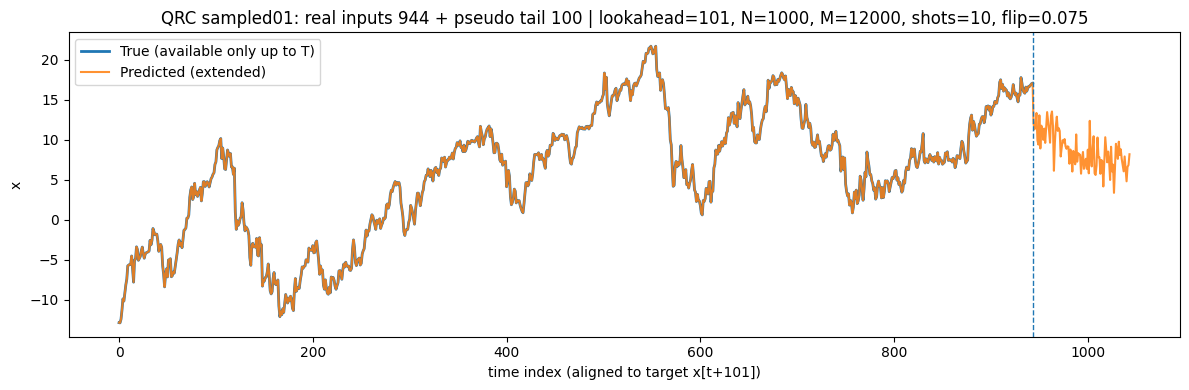

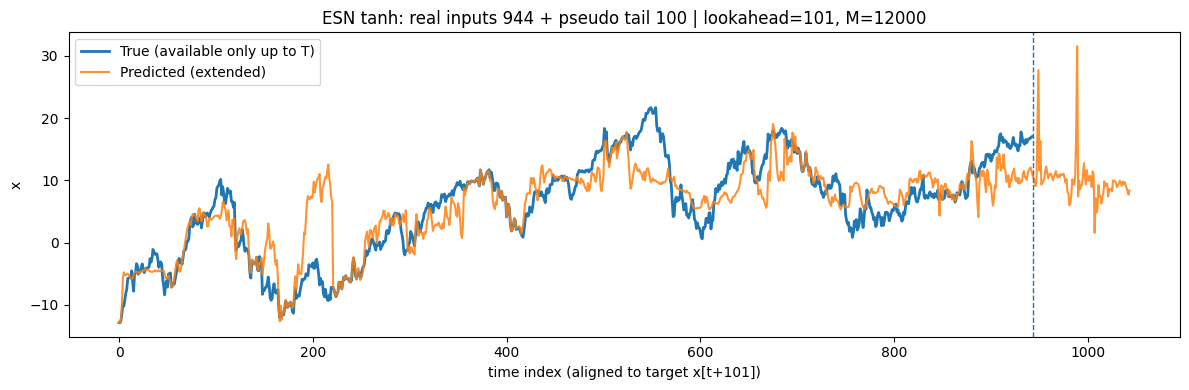

In [ ]:
res = compare_qrc_vs_esn_scalar_extend_sampled01_replaced(
    x_series_D,
    start_t=0,
    T_total=944,
    H_tail=100,
    lookahead=101,
    N=1000,
    shots=10,
    flip_p=0.075
)

(4-3)

In [ ]:
import numpy as np

def compare_qrc_vs_esn_scalar_shift100_predict_700_799_sampled01(
    x_series: np.ndarray,
    *,
    N: int = 1,
    seed: int = 43,

    # あなたの指定に合わせて固定（必要なら変えられるように引数化）
    start_t: int = 0,
    T_train: int = 600,      # 学習入力: x[start_t : start_t+600]
    T_pred: int = 100,       # 予測入力: x[start_t+600 : start_t+700]
    lookahead: int = 100,    # 教師: x[t+100]  → x[100:700], 予測出力は x[700:800]

    # QRC params
    alpha: float = 1.0,
    beta: float = 0.7,
    squeeze_r: float = 0.3,
    norm_const: float = 1.0,
    sign_mode: str = "plus",
    input_mode: str = "scale",
    Win_scale_qrc: float = 1.0,
    carry_state: bool = True,
    ridge: float = 1e-2,

    # QRC measurement (sampled01 + flip)
    shots: int = 1,
    flip_p: float = 0.0,

    # ESN params
    spectral_radius: float = 0.9,
    input_scale_esn: float = 0.5,
    leak_rate: float = 1.0,
    bias_scale: float = 0.1,
):
    """
    禁止事項：予測した出力を入力に戻さない（ロールアウトしない）

    学習:
      U_train = x[start_t : start_t+T_train]         (= x[0:600])
      Y_train = x[start_t+lookahead : start_t+lookahead+T_train] (= x[100:700])

    予測:
      U_pred  = x[start_t+T_train : start_t+T_train+T_pred] (= x[600:700])
      出力は yhat_pred (= x[700:800] の推定) を返す
    """

    x = np.asarray(x_series, float).reshape(-1)
    M = 12 * N

    # 必要なデータ長：入力として x[start_t : start_t+T_train+T_pred] が必要
    need_len_inputs = start_t + T_train + T_pred            # = 700
    # 学習ラベルとして x[start_t+lookahead : start_t+lookahead+T_train] が必要
    need_len_labels = start_t + lookahead + T_train         # = 700

    need_len = max(need_len_inputs, need_len_labels)
    if len(x) < need_len:
        raise ValueError(
            f"x_series is too short. need len >= {need_len}, got {len(x)}. "
            f"(inputs need {need_len_inputs}, labels need {need_len_labels})"
        )

    # --- データ定義（あなたの指定どおり） ---
    U_train = x[start_t : start_t + T_train]  # x[0:600]
    Y_train = x[start_t + lookahead : start_t + lookahead + T_train]  # x[100:700]
    U_pred  = x[start_t + T_train : start_t + T_train + T_pred]       # x[600:700]

    # 重要：状態列は「学習入力＋予測入力」まで流して作る（入力は実データのみ）
    U_all = np.concatenate([U_train, U_pred])  # x[0:700]  ※自己出力は混ぜない

    # =========================
    # QRC sampled01
    # =========================
    S_qrc_all, _, _, _ = simulate_qrc_states_sampled01_scalar(
        N=N, alpha=alpha, beta=beta, squeeze_r=squeeze_r,
        U=U_all,
        seed=seed,
        norm_const=norm_const,
        sign_mode=sign_mode,
        input_mode=input_mode,
        Win=None,
        Win_scale=Win_scale_qrc,
        carry_state=carry_state,
        shots=shots,
        flip_p=flip_p,
    )

    # 学習は t=0..599 の状態だけ
    S_qrc_train = S_qrc_all[:T_train]
    wq, bq = fit_readout_ridge(S_qrc_train, Y_train, ridge=ridge)

    # 予測（t=600..699 の状態にreadoutを当てる）→ x[700..799] の推定
    Yhat_qrc_all = predict_readout(S_qrc_all, wq, bq)          # 長さ700
    Yhat_qrc_pred = Yhat_qrc_all[T_train:T_train+T_pred]       # 長さ100（欲しい部分）

    mse_qrc, corr_qrc = mse_corr(Y_train, Yhat_qrc_all[:T_train])

    # =========================
    # ESN tanh
    # =========================
    S_esn_all, _ = simulate_esn_states_tanh_scalar(
        M=M, U=U_all,
        seed=seed,
        spectral_radius=spectral_radius,
        input_scale=input_scale_esn,
        leak_rate=leak_rate,
        bias_scale=bias_scale,
    )
    S_esn_train = S_esn_all[:T_train]
    we, be = fit_readout_ridge(S_esn_train, Y_train, ridge=ridge)

    Yhat_esn_all = predict_readout(S_esn_all, we, be)
    Yhat_esn_pred = Yhat_esn_all[T_train:T_train+T_pred]

    mse_esn, corr_esn = mse_corr(Y_train, Yhat_esn_all[:T_train])

    print(f"[QRC sampled01] M={M} shots={shots} flip={flip_p:.3f}  (train eval on {T_train}) MSE={mse_qrc:.6f} Corr={corr_qrc:.6f}")
    print(f"[ESN tanh]     M={M}                        (train eval on {T_train}) MSE={mse_esn:.6f} Corr={corr_esn:.6f}")
    print(f"Pred input range : x[{start_t+T_train}:{start_t+T_train+T_pred}] (length {T_pred})")
    print(f"Pred target range: x[{start_t+T_train+lookahead}:{start_t+T_train+lookahead+T_pred}] (unknown OK)")

    # プロット（Trueは学習区間だけ、Predは学習+予測入力ぶん）
    plot_true_and_pred_with_tail(
        Y_train, Yhat_qrc_all, T_pred,
        title=f"QRC sampled01: train x[0:600]->x[100:700], predict from x[600:700] -> x[700:800] (shift={lookahead})"
    )
    plot_true_and_pred_with_tail(
        Y_train, Yhat_esn_all, T_pred,
        title=f"ESN tanh: train x[0:600]->x[100:700], predict from x[600:700] -> x[700:800] (shift={lookahead})"
    )

    return {
        "Y_train": Y_train,                 # x[100:700] (600)
        "Yhat_qrc_pred": Yhat_qrc_pred,     # 予測ターゲット相当 x[700:800] (100)
        "Yhat_esn_pred": Yhat_esn_pred,     # 同上
        "Yhat_qrc_all": Yhat_qrc_all,       # 参考: t=0..699 の予測（= x[100:800] の一部推定）
        "Yhat_esn_all": Yhat_esn_all,
        "metrics_on_train": {
            "qrc": (mse_qrc, corr_qrc),
            "esn": (mse_esn, corr_esn),
        },
        "meta": {
            "start_t": start_t,
            "T_train": T_train,
            "T_pred": T_pred,
            "lookahead": lookahead,
            "required_len": max(need_len_inputs, need_len_labels),
        }
    }

[QRC sampled01] M=1200 shots=10 flip=0.075  (train eval on 944) MSE=0.001080 Corr=0.999992
[ESN tanh]     M=1200                        (train eval on 944) MSE=22.777634 Corr=0.787859
Pred input range : x[944:1044] (length 100)
Pred target range: x[1044:1144] (unknown OK)


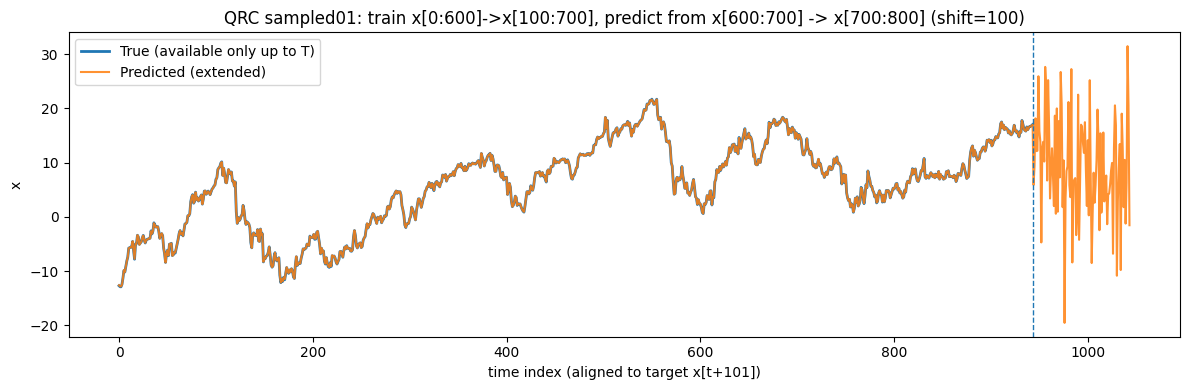

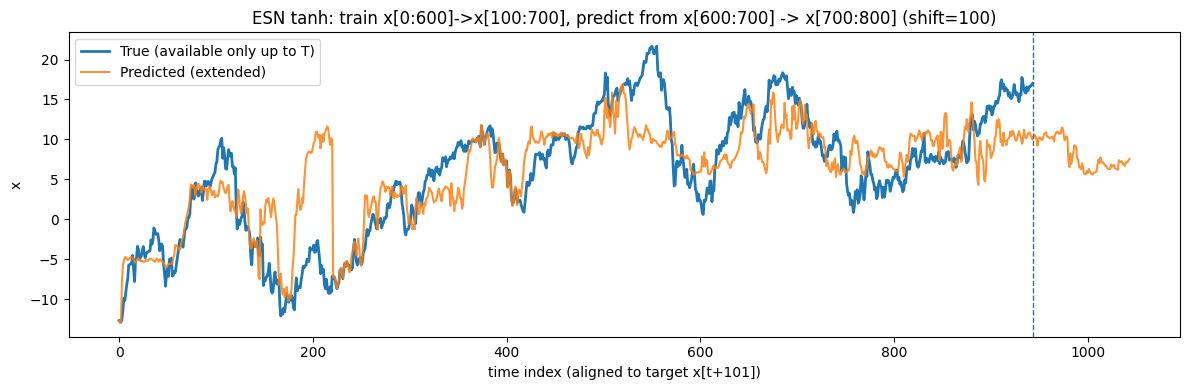

{'Y_train': array([-12.69, -12.86, -12.89, -12.45, -11.32,  -9.89, -10.17,  -9.14,
         -8.13,  -7.42,  -5.76,  -5.67,  -5.58,  -5.6 ,  -4.53,  -6.17,
         -7.8 ,  -5.04,  -4.92,  -3.39,  -3.74,  -5.07,  -4.83,  -4.57,
         -3.88,  -3.42,  -4.27,  -4.81,  -4.31,  -4.13,  -4.07,  -4.02,
         -3.92,  -2.58,  -3.14,  -2.58,  -1.1 ,  -1.47,  -1.88,  -1.82,
         -1.8 ,  -2.63,  -3.95,  -3.34,  -3.09,  -3.45,  -5.72,  -6.81,
         -8.39,  -6.84,  -6.14,  -7.15,  -5.03,  -5.  ,  -4.87,  -7.13,
         -7.  ,  -6.52,  -6.68,  -5.79,  -4.99,  -4.12,  -3.07,  -2.53,
         -3.22,  -2.89,  -3.5 ,  -2.48,  -1.31,  -1.21,  -1.04,   0.2 ,
          0.2 ,   0.59,   2.79,   3.7 ,   4.09,   2.52,   2.83,   4.55,
          3.15,   3.52,   2.91,   3.2 ,   3.72,   4.04,   2.35,   3.32,
          4.75,   4.76,   4.16,   4.45,   4.75,   4.53,   4.09,   4.63,
          5.12,   5.33,   5.68,   5.86,   6.91,   7.22,   8.74,   9.03,
          9.26,   9.89,  10.14,   7.64,   8.96,   7.9

In [ ]:
compare_qrc_vs_esn_scalar_shift100_predict_700_799_sampled01(
    x_series_D,
    N = 100,
    seed = 43,

    # あなたの指定に合わせて固定（必要なら変えられるように引数化）
    start_t = 0,
    T_train = 944,      # 学習入力: x[start_t : start_t+600]
    T_pred = 100,       # 予測入力: x[start_t+600 : start_t+700]
    lookahead = 100,    # 教師: x[t+100]  → x[100:700], 予測出力は x[700:800]

    # QRC params
    alpha = 1.0,
    beta = 0.7,
    squeeze_r = 0.3,
    norm_const = 1.0,
    sign_mode = "plus",
    input_mode = "scale",
    Win_scale_qrc = 1.0,
    carry_state = True,
    ridge = 1e-2,

    # QRC measurement (sampled01 + flip)
    shots = 10,
    flip_p = 0.075,

    # ESN params
    spectral_radius = 0.9,
    input_scale_esn = 0.5,
    leak_rate = 1.0,
    bias_scale = 0.1)

[QRC sampled01] M=12000 shots=10 flip=0.075  (train eval on 944) MSE=0.000000 Corr=1.000000
[ESN tanh]     M=12000                        (train eval on 944) MSE=17.833690 Corr=0.838568
Pred input range : x[944:1044] (length 100)
Pred target range: x[1044:1144] (unknown OK)


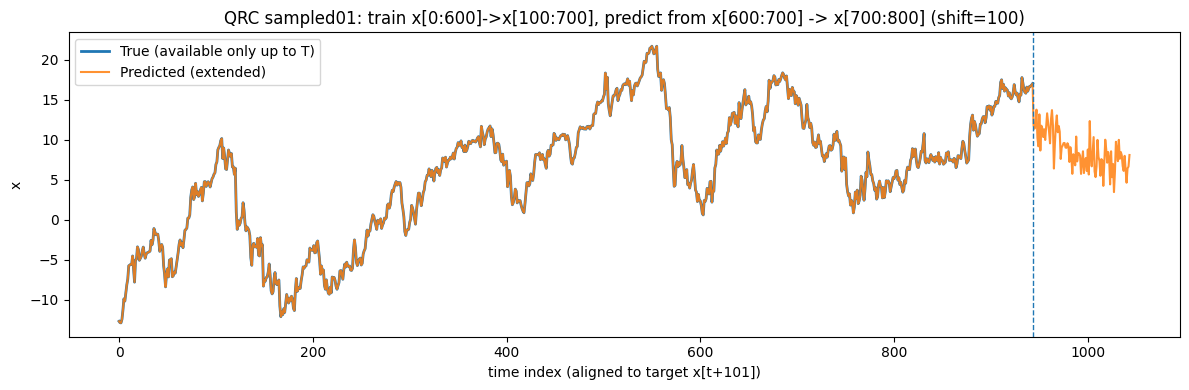

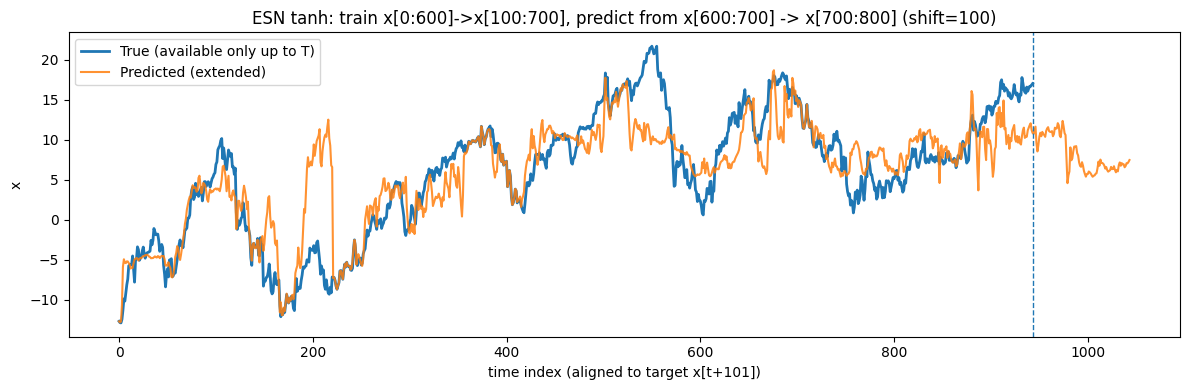

{'Y_train': array([-12.69, -12.86, -12.89, -12.45, -11.32,  -9.89, -10.17,  -9.14,
         -8.13,  -7.42,  -5.76,  -5.67,  -5.58,  -5.6 ,  -4.53,  -6.17,
         -7.8 ,  -5.04,  -4.92,  -3.39,  -3.74,  -5.07,  -4.83,  -4.57,
         -3.88,  -3.42,  -4.27,  -4.81,  -4.31,  -4.13,  -4.07,  -4.02,
         -3.92,  -2.58,  -3.14,  -2.58,  -1.1 ,  -1.47,  -1.88,  -1.82,
         -1.8 ,  -2.63,  -3.95,  -3.34,  -3.09,  -3.45,  -5.72,  -6.81,
         -8.39,  -6.84,  -6.14,  -7.15,  -5.03,  -5.  ,  -4.87,  -7.13,
         -7.  ,  -6.52,  -6.68,  -5.79,  -4.99,  -4.12,  -3.07,  -2.53,
         -3.22,  -2.89,  -3.5 ,  -2.48,  -1.31,  -1.21,  -1.04,   0.2 ,
          0.2 ,   0.59,   2.79,   3.7 ,   4.09,   2.52,   2.83,   4.55,
          3.15,   3.52,   2.91,   3.2 ,   3.72,   4.04,   2.35,   3.32,
          4.75,   4.76,   4.16,   4.45,   4.75,   4.53,   4.09,   4.63,
          5.12,   5.33,   5.68,   5.86,   6.91,   7.22,   8.74,   9.03,
          9.26,   9.89,  10.14,   7.64,   8.96,   7.9

In [ ]:
compare_qrc_vs_esn_scalar_shift100_predict_700_799_sampled01(
    x_series_D,
    N = 1000,
    seed = 43,

    # あなたの指定に合わせて固定（必要なら変えられるように引数化）
    start_t = 0,
    T_train = 944,      # 学習入力: x[start_t : start_t+600]
    T_pred = 100,       # 予測入力: x[start_t+600 : start_t+700]
    lookahead = 100,    # 教師: x[t+100]  → x[100:700], 予測出力は x[700:800]

    # QRC params
    alpha = 1.0,
    beta = 0.7,
    squeeze_r = 0.3,
    norm_const = 1.0,
    sign_mode = "plus",
    input_mode = "scale",
    Win_scale_qrc = 1.0,
    carry_state = True,
    ridge = 1e-2,

    # QRC measurement (sampled01 + flip)
    shots = 10,
    flip_p = 0.075,

    # ESN params
    spectral_radius = 0.9,
    input_scale_esn = 0.5,
    leak_rate = 1.0,
    bias_scale = 0.1)

[QRC sampled01] M=12000 shots=10 flip=0.000  (train eval on 944) MSE=0.000000 Corr=1.000000
[ESN tanh]     M=12000                        (train eval on 944) MSE=17.833690 Corr=0.838568
Pred input range : x[944:1044] (length 100)
Pred target range: x[1044:1144] (unknown OK)


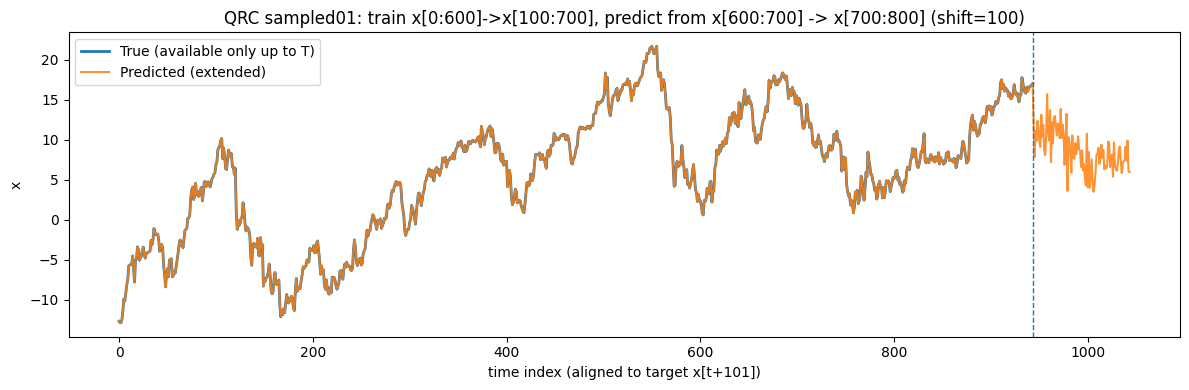

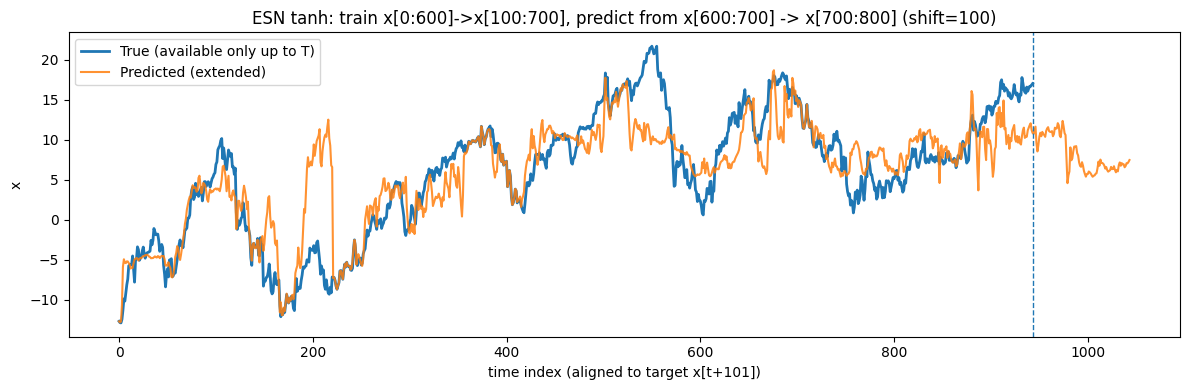

{'Y_train': array([-12.69, -12.86, -12.89, -12.45, -11.32,  -9.89, -10.17,  -9.14,
         -8.13,  -7.42,  -5.76,  -5.67,  -5.58,  -5.6 ,  -4.53,  -6.17,
         -7.8 ,  -5.04,  -4.92,  -3.39,  -3.74,  -5.07,  -4.83,  -4.57,
         -3.88,  -3.42,  -4.27,  -4.81,  -4.31,  -4.13,  -4.07,  -4.02,
         -3.92,  -2.58,  -3.14,  -2.58,  -1.1 ,  -1.47,  -1.88,  -1.82,
         -1.8 ,  -2.63,  -3.95,  -3.34,  -3.09,  -3.45,  -5.72,  -6.81,
         -8.39,  -6.84,  -6.14,  -7.15,  -5.03,  -5.  ,  -4.87,  -7.13,
         -7.  ,  -6.52,  -6.68,  -5.79,  -4.99,  -4.12,  -3.07,  -2.53,
         -3.22,  -2.89,  -3.5 ,  -2.48,  -1.31,  -1.21,  -1.04,   0.2 ,
          0.2 ,   0.59,   2.79,   3.7 ,   4.09,   2.52,   2.83,   4.55,
          3.15,   3.52,   2.91,   3.2 ,   3.72,   4.04,   2.35,   3.32,
          4.75,   4.76,   4.16,   4.45,   4.75,   4.53,   4.09,   4.63,
          5.12,   5.33,   5.68,   5.86,   6.91,   7.22,   8.74,   9.03,
          9.26,   9.89,  10.14,   7.64,   8.96,   7.9

In [ ]:
compare_qrc_vs_esn_scalar_shift100_predict_700_799_sampled01(
    x_series_D,
    N = 1000,
    seed = 43,

    # あなたの指定に合わせて固定（必要なら変えられるように引数化）
    start_t = 0,
    T_train = 944,      # 学習入力: x[start_t : start_t+600]
    T_pred = 100,       # 予測入力: x[start_t+600 : start_t+700]
    lookahead = 100,    # 教師: x[t+100]  → x[100:700], 予測出力は x[700:800]

    # QRC params
    alpha = 1.0,
    beta = 0.7,
    squeeze_r = 0.3,
    norm_const = 1.0,
    sign_mode = "plus",
    input_mode = "scale",
    Win_scale_qrc = 1.0,
    carry_state = True,
    ridge = 1e-2,

    # QRC measurement (sampled01 + flip)
    shots = 10,
    flip_p = 0.0,

    # ESN params
    spectral_radius = 0.9,
    input_scale_esn = 0.5,
    leak_rate = 1.0,
    bias_scale = 0.1)

[QRC sampled01] M=120 shots=10 flip=0.075  (train eval on 1034) MSE=17.323429 Corr=0.914388
[ESN tanh]     M=120                        (train eval on 1034) MSE=6.669558 Corr=0.967937
Pred input range : x[1034:1044] (length 10)
Pred target range: x[1044:1054] (unknown OK)


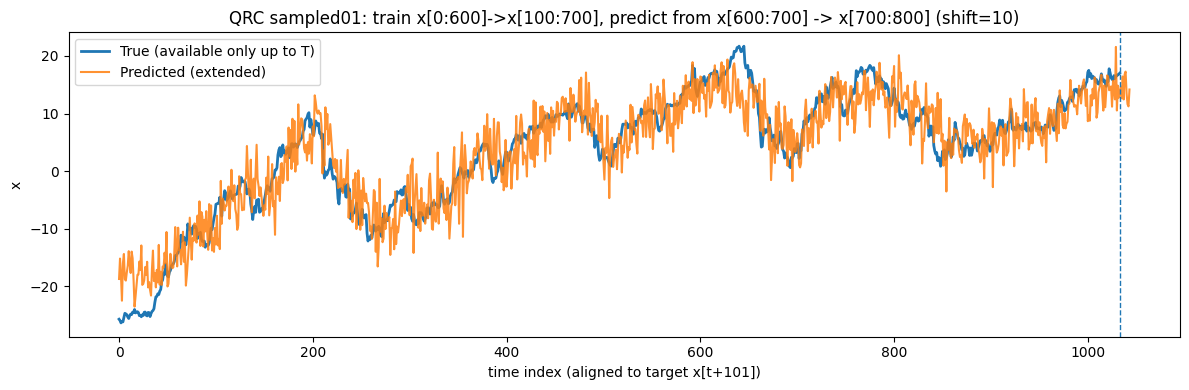

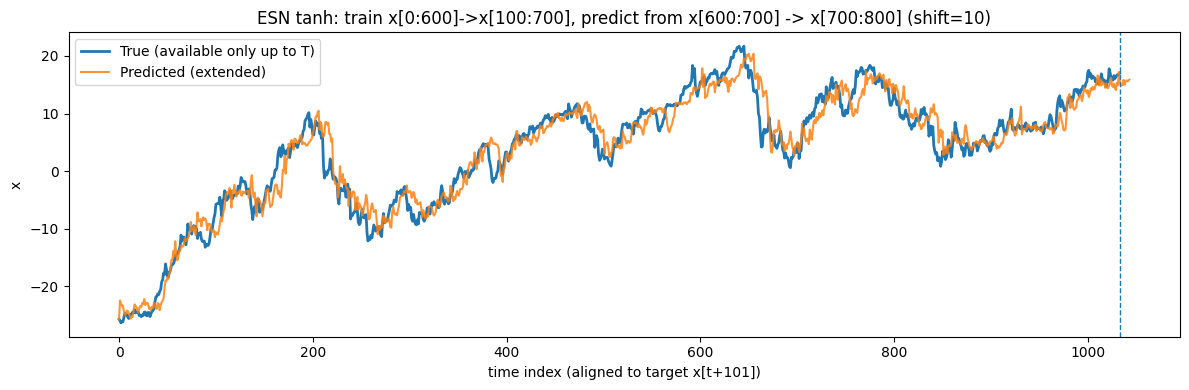

{'Y_train': array([-25.68, -25.91, -26.32, ...,  16.67,  16.84,  17.  ]),
 'Yhat_qrc_pred': array([14.66103104, 12.64170663, 16.41867541, 12.43787525, 16.78659147,
        17.2697842 , 13.51010888, 11.61262758, 11.23632989, 14.16550547]),
 'Yhat_esn_pred': array([14.7967767 , 14.95111321, 14.95209909, 15.83357506, 15.00147127,
        15.49975954, 15.74124806, 15.57724001, 15.76047336, 15.8862074 ]),
 'Yhat_qrc_all': array([-18.70474899, -15.16356452, -18.19128591, ...,  11.61262758,
         11.23632989,  14.16550547]),
 'Yhat_esn_all': array([-25.71812451, -22.43829645, -23.05843607, ...,  15.57724001,
         15.76047336,  15.8862074 ]),
 'metrics_on_train': {'qrc': (17.323428911199812, 0.9143879312445183),
  'esn': (6.669557575403655, 0.9679367468798533)},
 'meta': {'start_t': 0,
  'T_train': 1034,
  'T_pred': 10,
  'lookahead': 10,
  'required_len': 1044}}

In [ ]:
compare_qrc_vs_esn_scalar_shift100_predict_700_799_sampled01(
    x_series_D,
    N = 10,
    seed = 43,

    # あなたの指定に合わせて固定（必要なら変えられるように引数化）
    start_t = 0,
    T_train = 1034,      # 学習入力: x[start_t : start_t+600]
    T_pred = 10,       # 予測入力: x[start_t+600 : start_t+700]
    lookahead = 10,    # 教師: x[t+100]  → x[100:700], 予測出力は x[700:800]

    # QRC params
    alpha = 1.0,
    beta = 0.7,
    squeeze_r = 0.3,
    norm_const = 1.0,
    sign_mode = "plus",
    input_mode = "scale",
    Win_scale_qrc = 1.0,
    carry_state = True,
    ridge = 1e-2,

    # QRC measurement (sampled01 + flip)
    shots = 10,
    flip_p = 0.075,

    # ESN params
    spectral_radius = 0.9,
    input_scale_esn = 0.5,
    leak_rate = 1.0,
    bias_scale = 0.1)

[QRC sampled01] M=12000 shots=10 flip=0.075  (train eval on 1034) MSE=0.000000 Corr=1.000000
[ESN tanh]     M=12000                        (train eval on 1034) MSE=4.670698 Corr=0.977660
Pred input range : x[1034:1044] (length 10)
Pred target range: x[1044:1054] (unknown OK)


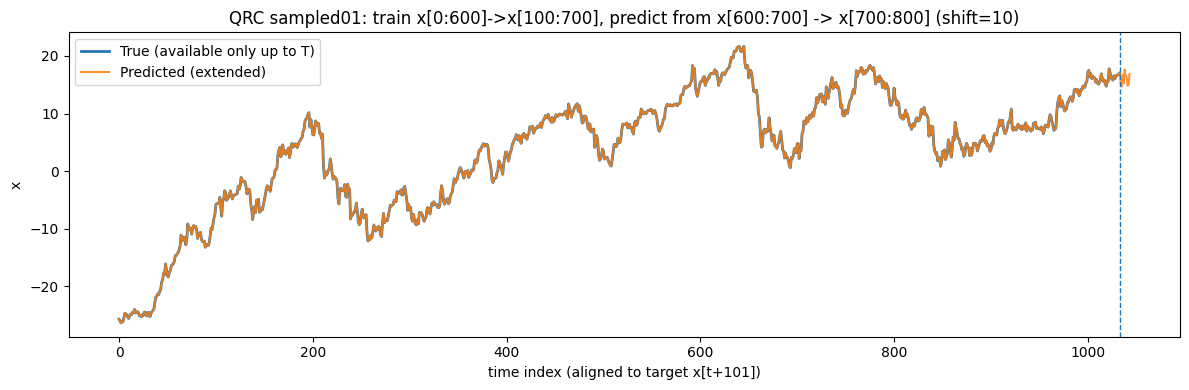

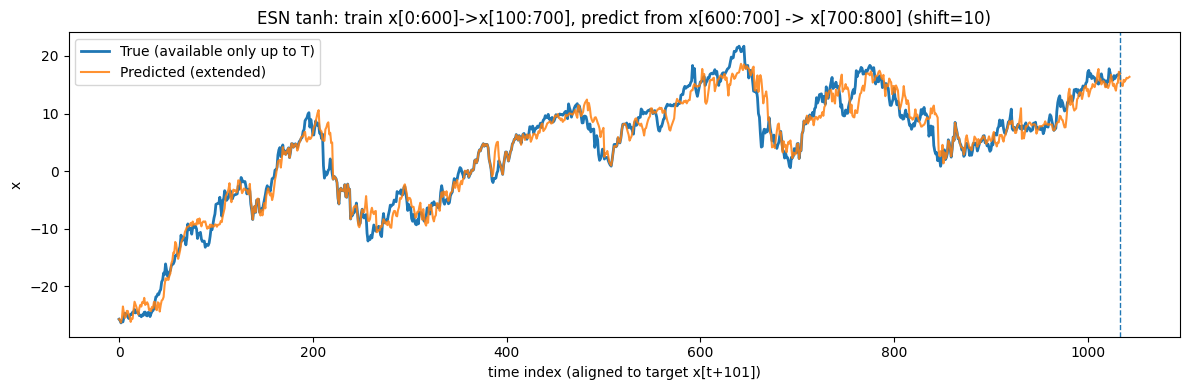

{'Y_train': array([-25.68, -25.91, -26.32, ...,  16.67,  16.84,  17.  ]),
 'Yhat_qrc_pred': array([15.18559848, 14.67912611, 16.66241895, 15.22461444, 17.59919501,
        16.62236632, 16.46453365, 14.87085653, 14.91048334, 16.81509428]),
 'Yhat_esn_pred': array([15.24795836, 14.91293613, 14.77817124, 15.83769815, 15.52519586,
        15.80832955, 16.19933973, 16.09810035, 16.23336356, 16.35892615]),
 'Yhat_qrc_all': array([-25.67965255, -25.90970507, -26.31959741, ...,  14.87085653,
         14.91048334,  16.81509428]),
 'Yhat_esn_all': array([-25.67997839, -25.91201416, -26.27482769, ...,  16.09810035,
         16.23336356,  16.35892615]),
 'metrics_on_train': {'qrc': (2.431899943927656e-08, 0.9999999998942929),
  'esn': (4.670697580704006, 0.977660288994949)},
 'meta': {'start_t': 0,
  'T_train': 1034,
  'T_pred': 10,
  'lookahead': 10,
  'required_len': 1044}}

In [ ]:
compare_qrc_vs_esn_scalar_shift100_predict_700_799_sampled01(
    x_series_D,
    N = 1000,
    seed = 43,

    # あなたの指定に合わせて固定（必要なら変えられるように引数化）
    start_t = 0,
    T_train = 1034,      # 学習入力: x[start_t : start_t+600]
    T_pred = 10,       # 予測入力: x[start_t+600 : start_t+700]
    lookahead = 10,    # 教師: x[t+100]  → x[100:700], 予測出力は x[700:800]

    # QRC params
    alpha = 1.0,
    beta = 0.7,
    squeeze_r = 0.3,
    norm_const = 1.0,
    sign_mode = "plus",
    input_mode = "scale",
    Win_scale_qrc = 1.0,
    carry_state = True,
    ridge = 1e-2,

    # QRC measurement (sampled01 + flip)
    shots = 10,
    flip_p = 0.075,

    # ESN params
    spectral_radius = 0.9,
    input_scale_esn = 0.5,
    leak_rate = 1.0,
    bias_scale = 0.1)

[QRC sampled01] M=12000 shots=10 flip=0.075  (train eval on 800) MSE=0.000000 Corr=1.000000
[ESN tanh]     M=12000                        (train eval on 800) MSE=17.545123 Corr=0.849645
Pred input range : x[800:900] (length 100)
Pred target range: x[900:1000] (unknown OK)


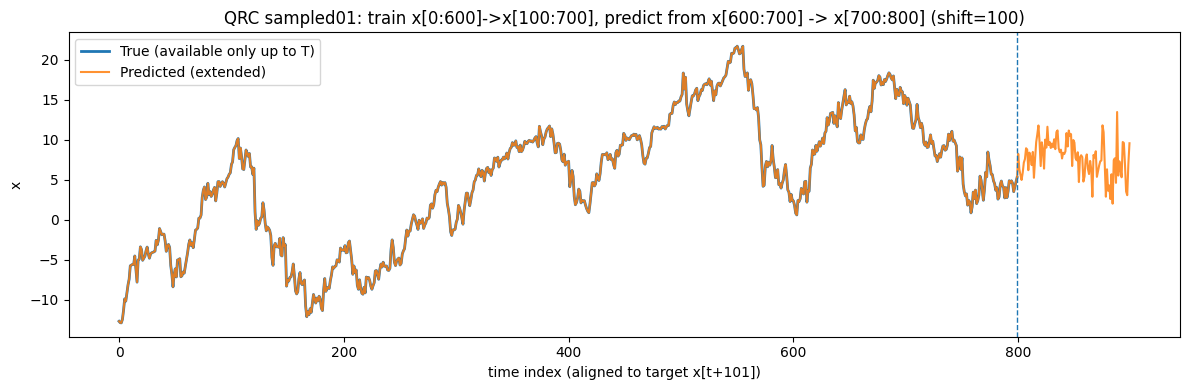

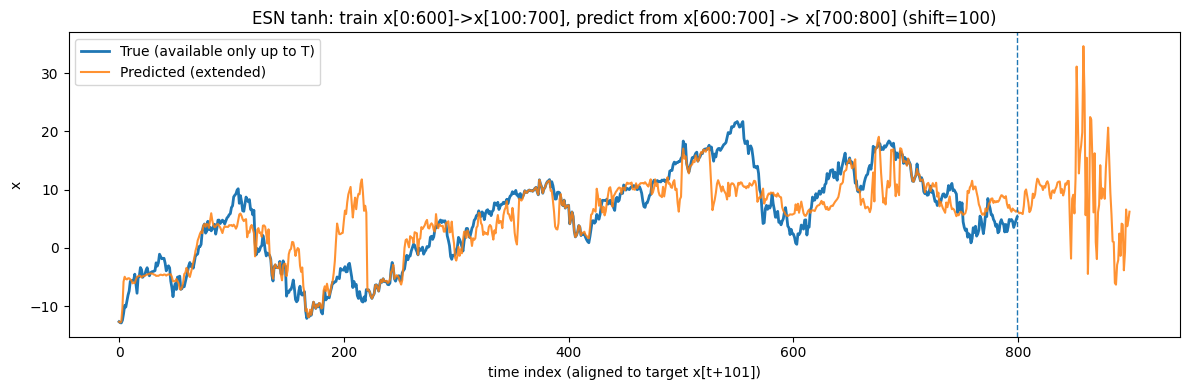

{'Y_train': array([-12.69, -12.86, -12.89, -12.45, -11.32,  -9.89, -10.17,  -9.14,
         -8.13,  -7.42,  -5.76,  -5.67,  -5.58,  -5.6 ,  -4.53,  -6.17,
         -7.8 ,  -5.04,  -4.92,  -3.39,  -3.74,  -5.07,  -4.83,  -4.57,
         -3.88,  -3.42,  -4.27,  -4.81,  -4.31,  -4.13,  -4.07,  -4.02,
         -3.92,  -2.58,  -3.14,  -2.58,  -1.1 ,  -1.47,  -1.88,  -1.82,
         -1.8 ,  -2.63,  -3.95,  -3.34,  -3.09,  -3.45,  -5.72,  -6.81,
         -8.39,  -6.84,  -6.14,  -7.15,  -5.03,  -5.  ,  -4.87,  -7.13,
         -7.  ,  -6.52,  -6.68,  -5.79,  -4.99,  -4.12,  -3.07,  -2.53,
         -3.22,  -2.89,  -3.5 ,  -2.48,  -1.31,  -1.21,  -1.04,   0.2 ,
          0.2 ,   0.59,   2.79,   3.7 ,   4.09,   2.52,   2.83,   4.55,
          3.15,   3.52,   2.91,   3.2 ,   3.72,   4.04,   2.35,   3.32,
          4.75,   4.76,   4.16,   4.45,   4.75,   4.53,   4.09,   4.63,
          5.12,   5.33,   5.68,   5.86,   6.91,   7.22,   8.74,   9.03,
          9.26,   9.89,  10.14,   7.64,   8.96,   7.9

In [ ]:
compare_qrc_vs_esn_scalar_shift100_predict_700_799_sampled01(
    x_series_D,
    N = 1000,
    seed = 43,

    # あなたの指定に合わせて固定（必要なら変えられるように引数化）
    start_t = 0,
    T_train = 800,      # 学習入力: x[start_t : start_t+600]
    T_pred = 100,       # 予測入力: x[start_t+600 : start_t+700]
    lookahead = 100,    # 教師: x[t+100]  → x[100:700], 予測出力は x[700:800]

    # QRC params
    alpha = 1.0,
    beta = 0.7,
    squeeze_r = 0.3,
    norm_const = 1.0,
    sign_mode = "plus",
    input_mode = "scale",
    Win_scale_qrc = 1.0,
    carry_state = True,
    ridge = 1e-2,

    # QRC measurement (sampled01 + flip)
    shots = 10,
    flip_p = 0.075,

    # ESN params
    spectral_radius = 0.9,
    input_scale_esn = 0.5,
    leak_rate = 1.0,
    bias_scale = 0.1)